<a href="https://colab.research.google.com/github/h77k/python-ai-Trunova-Polina/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий Полины в Google Colab
- Загружаем CSV-файлы:
  - `data/models.csv` — информация о моделях (тип, производитель, страна, дата выпуска, предшественники/наследники, размеры, масса)
  - `data/manufacturers.csv` — информация о производителях (страна, штаб-квартира, дата основания, отрасль)
- Приводим типы данных:
  - `startProduction` → `start_year` (целое число)
  - `predecessorLabel` / `successorLabel` — строки для построения графа родословной
  - `length`, `width`, `height`, `mass` → числовые значения
- Создаём производные признаки для визуализации поколений

**Результат:**
- Главная таблица `df_viz` (1 модель = 1 строка) с полями:
  - `model_name`, `type_name`, `manufacturer_name`, `country_name`, `start_year`
  - `predecessorLabel`, `successorLabel` — для построения lineage-графа
  - `length`, `width`, `height`, `mass`, `footprint`, `slenderness`
  - `manufacturer_inception_year`, `manufacturer_age_at_launch`
- Специальные выборки для графа родословной:
  - `df_lineage` — модели, у которых есть предшественник или наследник
  - `df_time` — модели с известным годом выпуска (ось X графа)

In [1]:
# ============================================================
# ЯЧЕЙКА 1. Подготовка данных для Lab 3:
# чтение CSV, диагностика, безопасный merge, готовые выборки
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# --- Базовые настройки ---
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")

# --- 1. Клонирование репозитория Полины ---
repo = "python-ai-Trunova-Polina"
repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/h77k/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}
print(f"✅ Работаем в репозитории: {repo}")

# --- 2. Чтение исходных CSV ---
df_raw = pd.read_csv("data/models.csv")
df_mfr_raw = pd.read_csv("data/manufacturers.csv")
print(f"✅ models.csv: {len(df_raw)} строк")
print(f"✅ manufacturers.csv: {len(df_mfr_raw)} строк")

# --- 3. Переименование столбцов: models ---
# ИЗМЕНЕНО: точно соответствует структуре models.csv
df = df_raw.rename(columns={
    "model": "URL",                    # ← было model, стало URL
    "modelLabel": "model_name",        # ← было modelLabel
    "typeLabel": "type_name",          # ← было typeLabel
    "manufacturerLabel": "manufacturer_name",  # ← было manufacturerLabel
    "countryLabel": "country_name",    # ← было countryLabel
    "startProduction": "start_production",    # ← было startProduction
    "predecessorLabel": "predecessorLabel",   # оставляем как есть
    "successorLabel": "successorLabel",       # оставляем как есть
}, errors="ignore").copy()

# --- 4. Переименование столбцов: manufacturers ---
# ИЗМЕНЕНО: точно соответствует структуре manufacturers.csv
df_mfr = df_mfr_raw.rename(columns={
    "manufacturer": "manufacturer_url",        # ← было manufacturer
    "manufacturerLabel": "manufacturer_name",  # ← было manufacturerLabel
    "countryLabel": "mfr_country",             # ← было countryLabel
    "hqLabel": "hq_name",                      # ← было hqLabel
    "inception": "manufacturer_inception",     # ← было inception
    "industryLabel": "industry_name",          # ← было industryLabel
}, errors="ignore").copy()

# --- 5. Приведение типов: models ---
for col in ["length", "width", "height", "mass"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Обработка start_production -> start_year
if "start_production" in df.columns:
    df["start_production"] = pd.to_datetime(df["start_production"], errors="coerce", utc=True)
    df["start_year"] = df["start_production"].dt.year
else:
    df["start_year"] = np.nan

# --- 6. Приведение типов: manufacturers ---
if "manufacturer_inception" in df_mfr.columns:
    df_mfr["manufacturer_inception"] = pd.to_datetime(df_mfr["manufacturer_inception"], errors="coerce", utc=True)
    df_mfr["manufacturer_inception_year"] = df_mfr["manufacturer_inception"].dt.year
else:
    df_mfr["manufacturer_inception_year"] = np.nan

# --- 7. Гарантируем наличие ключевых столбцов для lineage графа ---
# ИЗМЕНЕНО: добавлены predecessorLabel и successorLabel как обязательные
needed_model_cols = [
    "URL", "model_name", "type", "type_name", "manufacturer", "manufacturer_name",
    "country_name", "start_production", "start_year",
    "predecessorLabel", "successorLabel",  # ключевые для графа родословной
    "length", "width", "height", "mass", "image"
]
for col in needed_model_cols:
    if col not in df.columns:
        df[col] = np.nan

needed_mfr_cols = [
    "manufacturer_url", "manufacturer_name", "mfr_country", "hq_name",
    "manufacturer_inception", "manufacturer_inception_year",
    "industry_name", "website_url", "logo_url", "mfr_image"
]
for col in needed_mfr_cols:
    if col not in df_mfr.columns:
        df_mfr[col] = np.nan

# --- 8. Диагностика длинного формата: models ---
n_rows_models = len(df)
n_unique_models = df["URL"].nunique(dropna=True)
avg_rows_per_model = n_rows_models / n_unique_models if n_unique_models else np.nan
model_dup_counts = df["URL"].value_counts(dropna=True)
dup_distribution = (
    model_dup_counts.value_counts()
    .sort_index()
    .rename_axis("строк_на_модель")
    .reset_index(name="сколько_моделей")
)
print("\n=== ДЛИННЫЙ ФОРМАТ: MODELS ===")
print(f"Всего строк: {n_rows_models}")
print(f"Уникальных моделей по URL: {n_unique_models}")
print(f"Среднее число строк на одну модель: {avg_rows_per_model:.2f}")
display(dup_distribution.head(10))

# --- 9. Диагностика длинного формата: manufacturers ---
n_rows_mfr = len(df_mfr)
n_unique_mfr = df_mfr["manufacturer_url"].nunique(dropna=True)
avg_rows_per_mfr = n_rows_mfr / n_unique_mfr if n_unique_mfr else np.nan
mfr_dup_counts = df_mfr["manufacturer_url"].value_counts(dropna=True)
mfr_dup_distribution = (
    mfr_dup_counts.value_counts()
    .sort_index()
    .rename_axis("строк_на_производителя")
    .reset_index(name="сколько_производителей")
)
print("\n=== ДЛИННЫЙ ФОРМАТ: MANUFACTURERS ===")
print(f"Всего строк: {n_rows_mfr}")
print(f"Уникальных производителей по manufacturer_url: {n_unique_mfr}")
print(f"Среднее число строк на одного производителя: {avg_rows_per_mfr:.2f}")
display(mfr_dup_distribution.head(10))

# --- 10. Fill Rate: models ---
optional_model_cols = [
    "type_name", "country_name", "start_year",
    "predecessorLabel", "successorLabel",
    "length", "width", "height", "mass", "image"
]
optional_model_cols = [c for c in optional_model_cols if c in df.columns]
fill_rate_models = (
    pd.Series({c: df[c].notna().mean() * 100 for c in optional_model_cols}, name="fill_rate_%")
    .sort_values(ascending=False)
    .round(1)
    .reset_index()
    .rename(columns={"index": "field"})
)

# --- 11. Fill Rate: manufacturers ---
optional_mfr_cols = [
    "mfr_country", "hq_name", "manufacturer_inception_year",
    "industry_name", "website_url", "logo_url", "mfr_image"
]
optional_mfr_cols = [c for c in optional_mfr_cols if c in df_mfr.columns]
fill_rate_mfr = (
    pd.Series({c: df_mfr[c].notna().mean() * 100 for c in optional_mfr_cols}, name="fill_rate_%")
    .sort_values(ascending=False)
    .round(1)
    .reset_index()
    .rename(columns={"index": "field"})
)
print("\n=== FILL RATE: MODELS ===")
display(fill_rate_models)
print("\n=== FILL RATE: MANUFACTURERS ===")
display(fill_rate_mfr)

rare_model_fields = fill_rate_models.loc[fill_rate_models["fill_rate_%"] < 15, "field"].tolist()
rare_mfr_fields = fill_rate_mfr.loc[fill_rate_mfr["fill_rate_%"] < 15, "field"].tolist()
print("Редкие поля models (<15%):", rare_model_fields if rare_model_fields else "нет")
print("Редкие поля manufacturers (<15%):", rare_mfr_fields if rare_mfr_fields else "нет")

# --- 12. Проверка QID вместо читаемой метки в type_name ---
type_labels = (
    df[["URL", "type_name"]]
    .dropna()
    .drop_duplicates()
    .copy()
)
type_labels["is_qid_type"] = type_labels["type_name"].astype(str).str.fullmatch(r"Q\d+")
qid_type_share = type_labels["is_qid_type"].mean() * 100 if len(type_labels) else np.nan
print(f"\nДоля type_name, которые выглядят как QID: {qid_type_share:.1f}%")
qid_examples = type_labels[type_labels["is_qid_type"]].head(10)
if not qid_examples.empty:
    print("Примеры type_name = QID:")
    display(qid_examples)

# --- 13. Создаём df_unique: одна строка на одну модель ---
df["_nonnull_count"] = df.notna().sum(axis=1)
df_unique = (
    df.sort_values(["URL", "_nonnull_count"], ascending=[True, False])
      .drop_duplicates(subset="URL")
      .drop(columns="_nonnull_count")
      .copy()
)

# --- 14. Сохраняем информацию о многозначных типах отдельно ---
def unique_list(series):
    vals = [x for x in series.dropna().astype(str).str.strip() if x]
    vals = sorted(set(vals))
    return vals

def first_mode_or_first(series):
    s = series.dropna().astype(str).str.strip()
    s = s[s != ""]
    if s.empty:
        return np.nan
    mode = s.mode()
    return mode.iloc[0] if not mode.empty else s.iloc[0]

df_model_types = (
    df.groupby("URL", dropna=True)
      .agg(
          n_type_rows=("type_name", "count"),
          n_types=("type_name", pd.Series.nunique),
          type_names=("type_name", unique_list),
          primary_type=("type_name", first_mode_or_first)
      )
      .reset_index()
)

# --- 15. Готовим уникальную таблицу производителей ---
df_mfr_industry = (
    df_mfr.groupby("manufacturer_url", dropna=True)
          .agg(
              n_industries=("industry_name", pd.Series.nunique),
              industry_names=("industry_name", unique_list),
              primary_industry=("industry_name", first_mode_or_first)
          )
          .reset_index()
)

df_mfr_unique = (
    df_mfr.groupby("manufacturer_url", dropna=True)
          .agg(
              manufacturer_name=("manufacturer_name", "first"),
              mfr_country=("mfr_country", "first"),
              hq_name=("hq_name", "first"),
              manufacturer_inception=("manufacturer_inception", "first"),
              manufacturer_inception_year=("manufacturer_inception_year", "first"),
              website_url=("website_url", "first"),
              logo_url=("logo_url", "first"),
              mfr_image=("mfr_image", "first")
          )
          .reset_index()
          .merge(df_mfr_industry, on="manufacturer_url", how="left", validate="one_to_one")
)

# --- 16. Безопасный merge для визуализации ---
rows_before_merge = len(df_unique)
df_viz = df_unique.merge(
    df_model_types,
    on="URL",
    how="left",
    validate="one_to_one"
)
df_viz = df_viz.merge(
    df_mfr_unique,
    left_on="manufacturer",
    right_on="manufacturer_url",
    how="left",
    validate="many_to_one",
    indicator="_mfr_merge"
)

print("\n=== ПРОВЕРКА MERGE ===")
print(f"Строк до merge: {rows_before_merge}")
print(f"Строк после merge: {len(df_viz)}")
print(f"Уникальных моделей после merge: {df_viz['URL'].nunique(dropna=True)}")
print("Статус совпадений по производителям:")
display(df_viz["_mfr_merge"].value_counts(dropna=False).rename_axis("merge_status").reset_index(name="rows"))

# --- 17. Производные признаки для графа родословной и временной оси ---
for col in ["length", "width", "height", "mass", "start_year", "manufacturer_inception_year"]:
    if col in df_viz.columns:
        df_viz[col] = pd.to_numeric(df_viz[col], errors="coerce")

df_viz["footprint"] = df_viz["length"] * df_viz["width"]
df_viz["slenderness"] = df_viz["length"] / df_viz["width"]
df_viz["height_to_width"] = df_viz["height"] / df_viz["width"]
df_viz["manufacturer_age_at_launch"] = df_viz["start_year"] - df_viz["manufacturer_inception_year"]

# Защита от бессмысленных значений
df_viz.loc[df_viz["manufacturer_age_at_launch"] < 0, "manufacturer_age_at_launch"] = np.nan
df_viz.loc[df_viz["slenderness"] <= 0, "slenderness"] = np.nan
df_viz.loc[df_viz["height_to_width"] <= 0, "height_to_width"] = np.nan
df_viz.loc[df_viz["footprint"] <= 0, "footprint"] = np.nan

# --- 18. Удобное поле типа для графиков (очищаем от QID) ---
df_viz["type_for_viz"] = df_viz["primary_type"].copy()
df_viz["type_for_viz"] = df_viz["type_for_viz"].where(
    ~df_viz["type_for_viz"].astype(str).str.fullmatch(r"Q\d+"),
    np.nan
)

# --- 19. Отдельная таблица частот типов без QID ---
df_types_readable = (
    df[["URL", "type_name"]]
    .dropna()
    .drop_duplicates()
    .copy()
)
df_types_readable = df_types_readable[
    ~df_types_readable["type_name"].astype(str).str.fullmatch(r"Q\d+")
]
df_type_counts = (
    df_types_readable["type_name"]
    .value_counts()
    .rename_axis("type_name")
    .reset_index(name="n_models")
)

# "Ядро" данных: типы, где хотя бы 10 моделей
core_types = df_type_counts.loc[df_type_counts["n_models"] >= 10, "type_name"].tolist()
core_urls = (
    df_types_readable[df_types_readable["type_name"].isin(core_types)]["URL"]
    .drop_duplicates()
)
df_core = df_viz[df_viz["URL"].isin(core_urls)].copy()

# --- 20. ГОТОВЫЕ ВЫБОРКИ ДЛЯ ГРАФА ТЕХНОЛОГИЧЕСКОЙ РОДОСЛОВНОЙ ---
# ИЗМЕНЕНО: созданы выборки, которые точно нужны для time-DAG по методичке
df_time = df_viz[df_viz["start_year"].notna()].copy()
df_dims = df_viz[
    df_viz[["length", "width", "height"]].notna().all(axis=1)
].copy()
df_mass = df_viz[df_viz["mass"].notna()].copy()

# КЛЮЧЕВАЯ ВЫБОРКА ДЛЯ ГРАФА: модели, у которых есть lineage-связи
df_lineage = df_viz[
    df_viz[["predecessorLabel", "successorLabel"]].notna().any(axis=1)
].copy()

df_mfr_age = df_viz[
    df_viz[["start_year", "manufacturer_inception_year", "manufacturer_age_at_launch"]].notna().all(axis=1)
].copy()

# ДОПОЛНИТЕЛЬНО: выборка для графа с известным годом И lineage
df_lineage_time = df_viz[
    df_viz["start_year"].notna() &
    df_viz[["predecessorLabel", "successorLabel"]].notna().any(axis=1)
].copy()
print(f"\n✅ Для time-DAG графа: {len(df_lineage_time)} моделей с годом выпуска и lineage-связями")

# --- 21. Короткая сводка для выбора графиков ---
sample_summary = pd.DataFrame({
    "dataset": ["df_viz", "df_core", "df_time", "df_dims", "df_mass", "df_lineage", "df_mfr_age", "df_lineage_time"],
    "rows": [
        len(df_viz),
        len(df_core),
        len(df_time),
        len(df_dims),
        len(df_mass),
        len(df_lineage),
        len(df_mfr_age),
        len(df_lineage_time)
    ],
    "description": [
        "1 строка = 1 модель, основная таблица для Lab 3",
        "модели из часто встречающихся читаемых типов",
        "есть год начала производства (для оси X графа)",
        "есть длина, ширина и высота",
        "есть масса",
        "🌟 есть predecessor и/или successor — основа для графа родословной",
        "известен возраст производителя на момент запуска модели",
        "🌟 time-DAG: есть И год, И lineage-связи"
    ]
})
print("\n=== ГОТОВЫЕ ВЫБОРКИ ДЛЯ ГРАФИКОВ ===")
display(sample_summary)

# --- 22. Мини-диагностика выбросов для числовых полей ---
numeric_cols = ["start_year", "length", "width", "height", "mass", "footprint", "slenderness", "manufacturer_age_at_launch"]
numeric_cols = [c for c in numeric_cols if c in df_viz.columns]
outlier_report = []
for col in numeric_cols:
    s = df_viz[col].dropna()
    if len(s) >= 5:
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        n_out = ((df_viz[col] < low) | (df_viz[col] > high)).sum()
        outlier_report.append([col, round(low, 2), round(high, 2), int(n_out)])
outlier_report = pd.DataFrame(outlier_report, columns=["field", "low_iqr", "high_iqr", "n_outliers"])
print("\n=== ПРЕДВАРИТЕЛЬНАЯ ДИАГНОСТИКА ВЫБРОСОВ ===")
display(outlier_report)

# --- 23. Финальные объекты, с которыми удобно работать дальше ---
print("\n✅ Готово.")
print("Основные DataFrame:")
print("- df_raw, df_mfr_raw  -> сырые CSV")
print("- df, df_mfr          -> очищенные длинные таблицы")
print("- df_unique           -> 1 строка = 1 модель")
print("- df_mfr_unique       -> 1 строка = 1 производитель")
print("- df_viz              -> главная таблица для визуализаций")
print("- df_core, df_time, df_dims, df_mass, df_mfr_age -> готовые подвыборки")
print("- 🌟 df_lineage       -> модели с lineage-связями (для графа родословной)")
print("- 🌟 df_lineage_time  -> time-DAG: год + lineage (рекомендован преподавателем)")

/content/python-ai-Trunova-Polina
✅ Работаем в репозитории: python-ai-Trunova-Polina
✅ models.csv: 1929 строк
✅ manufacturers.csv: 18 строк

=== ДЛИННЫЙ ФОРМАТ: MODELS ===
Всего строк: 1929
Уникальных моделей по URL: 1666
Среднее число строк на одну модель: 1.16


,строк_на_модель,сколько_моделей
0,1,1474
1,2,165
2,3,3
3,4,20
4,6,2
5,8,1
6,16,1



=== ДЛИННЫЙ ФОРМАТ: MANUFACTURERS ===
Всего строк: 18
Уникальных производителей по manufacturer_url: 9
Среднее число строк на одного производителя: 2.00


,строк_на_производителя,сколько_производителей
0,1,3
1,2,4
2,3,1
3,4,1



=== FILL RATE: MODELS ===


...


✅ Для time-DAG графа: 12 моделей с годом выпуска и lineage-связями

=== ГОТОВЫЕ ВЫБОРКИ ДЛЯ ГРАФИКОВ ===


,dataset,rows,description
0,df_viz,1666,"1 строка = 1 модель, основная таблица для Lab 3"
1,df_core,1535,модели из часто встречающихся читаемых типов
2,df_time,23,есть год начала производства (для оси X графа)
3,df_dims,305,"есть длина, ширина и высота"
4,df_mass,163,есть масса
5,df_lineage,712,🌟 есть predecessor и/или successor — основа дл...
6,df_mfr_age,22,известен возраст производителя на момент запус...
7,df_lineage_time,12,"🌟 time-DAG: есть И год, И lineage-связи"



=== ПРЕДВАРИТЕЛЬНАЯ ДИАГНОСТИКА ВЫБРОСОВ ===


,field,low_iqr,high_iqr,n_outliers
0,start_year,1966.50,2042.50,4
1,length,2920.50,6120.50,32
2,width,1370.00,2210.00,32
3,height,1000.25,2054.25,35
4,mass,-281.00,2975.00,10
5,footprint,3608155.12,12681508.12,25
6,slenderness,2.00,3.09,14
7,manufacturer_age_at_launch,-86.00,200.00,0



✅ Готово.
Основные DataFrame:
- df_raw, df_mfr_raw  -> сырые CSV
- df, df_mfr          -> очищенные длинные таблицы
- df_unique           -> 1 строка = 1 модель
- df_mfr_unique       -> 1 строка = 1 производитель
- df_viz              -> главная таблица для визуализаций
- df_core, df_time, df_dims, df_mass, df_mfr_age -> готовые подвыборки
- 🌟 df_lineage       -> модели с lineage-связями (для графа родословной)
- 🌟 df_lineage_time  -> time-DAG: год + lineage (рекомендован преподавателем)


In [2]:
# ============================================================
# ЯЧЕЙКА 2. Быстрая проверка данных для графа родословной
# ============================================================

print("🔍 БЫСТРАЯ ДИАГНОСТИКА ДЛЯ TIME-DAG (ВАРИАНТ 1 ПРЕПОДАВАТЕЛЯ)")
print("=" * 60)

# 1. Общая статистика по lineage
n_with_predecessor = df_viz["predecessorLabel"].notna().sum()
n_with_successor = df_viz["successorLabel"].notna().sum()
n_with_any_lineage = df_lineage.shape[0]

print(f"\n📊 Статистика lineage-связей:")
print(f"   - Моделей с predecessorLabel: {n_with_predecessor}")
print(f"   - Моделей с successorLabel: {n_with_successor}")
print(f"   - Моделей хотя бы с одной связью: {n_with_any_lineage}")

# 2. Статистика для time-DAG
print(f"\n📊 Статистика для time-DAG (ось X = год):")
print(f"   - Моделей с известным годом: {len(df_time)}")
print(f"   - Моделей с годом И lineage: {len(df_lineage_time)}")
print(f"   - Процент от всех моделей: {len(df_lineage_time)/len(df_viz)*100:.1f}%")

# 3. Примеры связей для проверки структуры
print("\n🔗 Примеры lineage-связей (первые 10):")
lineage_examples = df_viz[
    df_viz["predecessorLabel"].notna() | df_viz["successorLabel"].notna()
][["model_name", "type_name", "start_year", "predecessorLabel", "successorLabel"]].head(10)
display(lineage_examples)

# 4. Распределение по десятилетиям (для черновика B по методичке)
df_lineage_time["decade"] = (df_lineage_time["start_year"] // 10) * 10
decade_counts = df_lineage_time["decade"].value_counts().sort_index()
print("\n📅 Распределение моделей с lineage по десятилетиям:")
for decade, count in decade_counts.items():
    print(f"   {int(decade)}-е: {count} моделей")

# 5. Предупреждение о разреженности (если нужно)
if len(df_lineage_time) < 30:
    print("\n⚠️ ВНИМАНИЕ: выборка для time-DAG небольшая (<30 моделей).")
    print("   Преподаватель рекомендует:")
    print("   - Черновик B: группировка по десятилетиям")
    print("   - Черновик C: только крупнейшие компоненты графа")
    print("   - Полный граф может выглядеть как 'лапша' — это нормально для черновика A")

print("\n✅ Диагностика завершена. Можно переходить к построению time-DAG.")
print("Рекомендуемый порядок черновиков (по методичке):")
print("   1. Черновик A: полный time-DAG (даже если лапша)")
print("   2. Черновик B: по десятилетиям")
print("   3. Черновик C: только крупнейшие компоненты")

🔍 БЫСТРАЯ ДИАГНОСТИКА ДЛЯ TIME-DAG (ВАРИАНТ 1 ПРЕПОДАВАТЕЛЯ)

📊 Статистика lineage-связей:
   - Моделей с predecessorLabel: 560
   - Моделей с successorLabel: 510
   - Моделей хотя бы с одной связью: 712

📊 Статистика для time-DAG (ось X = год):
   - Моделей с известным годом: 23
   - Моделей с годом И lineage: 12
   - Процент от всех моделей: 0.7%

🔗 Примеры lineage-связей (первые 10):


,model_name,type_name,start_year,predecessorLabel,successorLabel
0,ГАЗ-53,модель грузовика,NaN,ГАЗ-51,ГАЗ-3307
9,Volkswagen Bora (Китай),модель автомобиля,NaN,Volkswagen New Bora,NaN
44,Mercedes-Benz 170S,модель автомобиля,NaN,Mercedes-Benz W136,NaN
45,Ford Pinto,модель автомобиля,NaN,Ford Cortina,Ford Escort (Северная Америка)
55,Maybach 62,модель автомобиля,NaN,Mercedes-Benz W100,Mercedes-Benz S-Класс
67,Chrysler Pacifica,модель автомобиля,NaN,NaN,Dodge Journey
71,Škoda Slavia,модель автомобиля,NaN,Škoda Rapid (2011),NaN
72,"Ford Ranger (T6, first generation)",модель автомобиля,NaN,NaN,"Ford Ranger (T6, second generation)"
73,"Ford Ranger (T6, second generation)",модель автомобиля,NaN,"Ford Ranger (T6, first generation)",NaN
76,Mercedes-Benz W415,модель автомобиля,NaN,Mercedes-Benz Vaneo,NaN



📅 Распределение моделей с lineage по десятилетиям:
   1900-е: 1 моделей
   1930-е: 1 моделей
   1940-е: 1 моделей
   1960-е: 1 моделей
   1970-е: 1 моделей
   1990-е: 1 моделей
   2000-е: 3 моделей
   2010-е: 3 моделей

⚠️ ВНИМАНИЕ: выборка для time-DAG небольшая (<30 моделей).
   Преподаватель рекомендует:
   - Черновик B: группировка по десятилетиям
   - Черновик C: только крупнейшие компоненты графа
   - Полный граф может выглядеть как 'лапша' — это нормально для черновика A

✅ Диагностика завершена. Можно переходить к построению time-DAG.
Рекомендуемый порядок черновиков (по методичке):
   1. Черновик A: полный time-DAG (даже если лапша)
   2. Черновик B: по десятилетиям
   3. Черновик C: только крупнейшие компоненты


📊 Строим граф на 12 моделях с известным годом и lineage
🔗 Построено 16 уникальных связей предшественник→наследник
🌐 Граф: 26 узлов, 16 рёбер


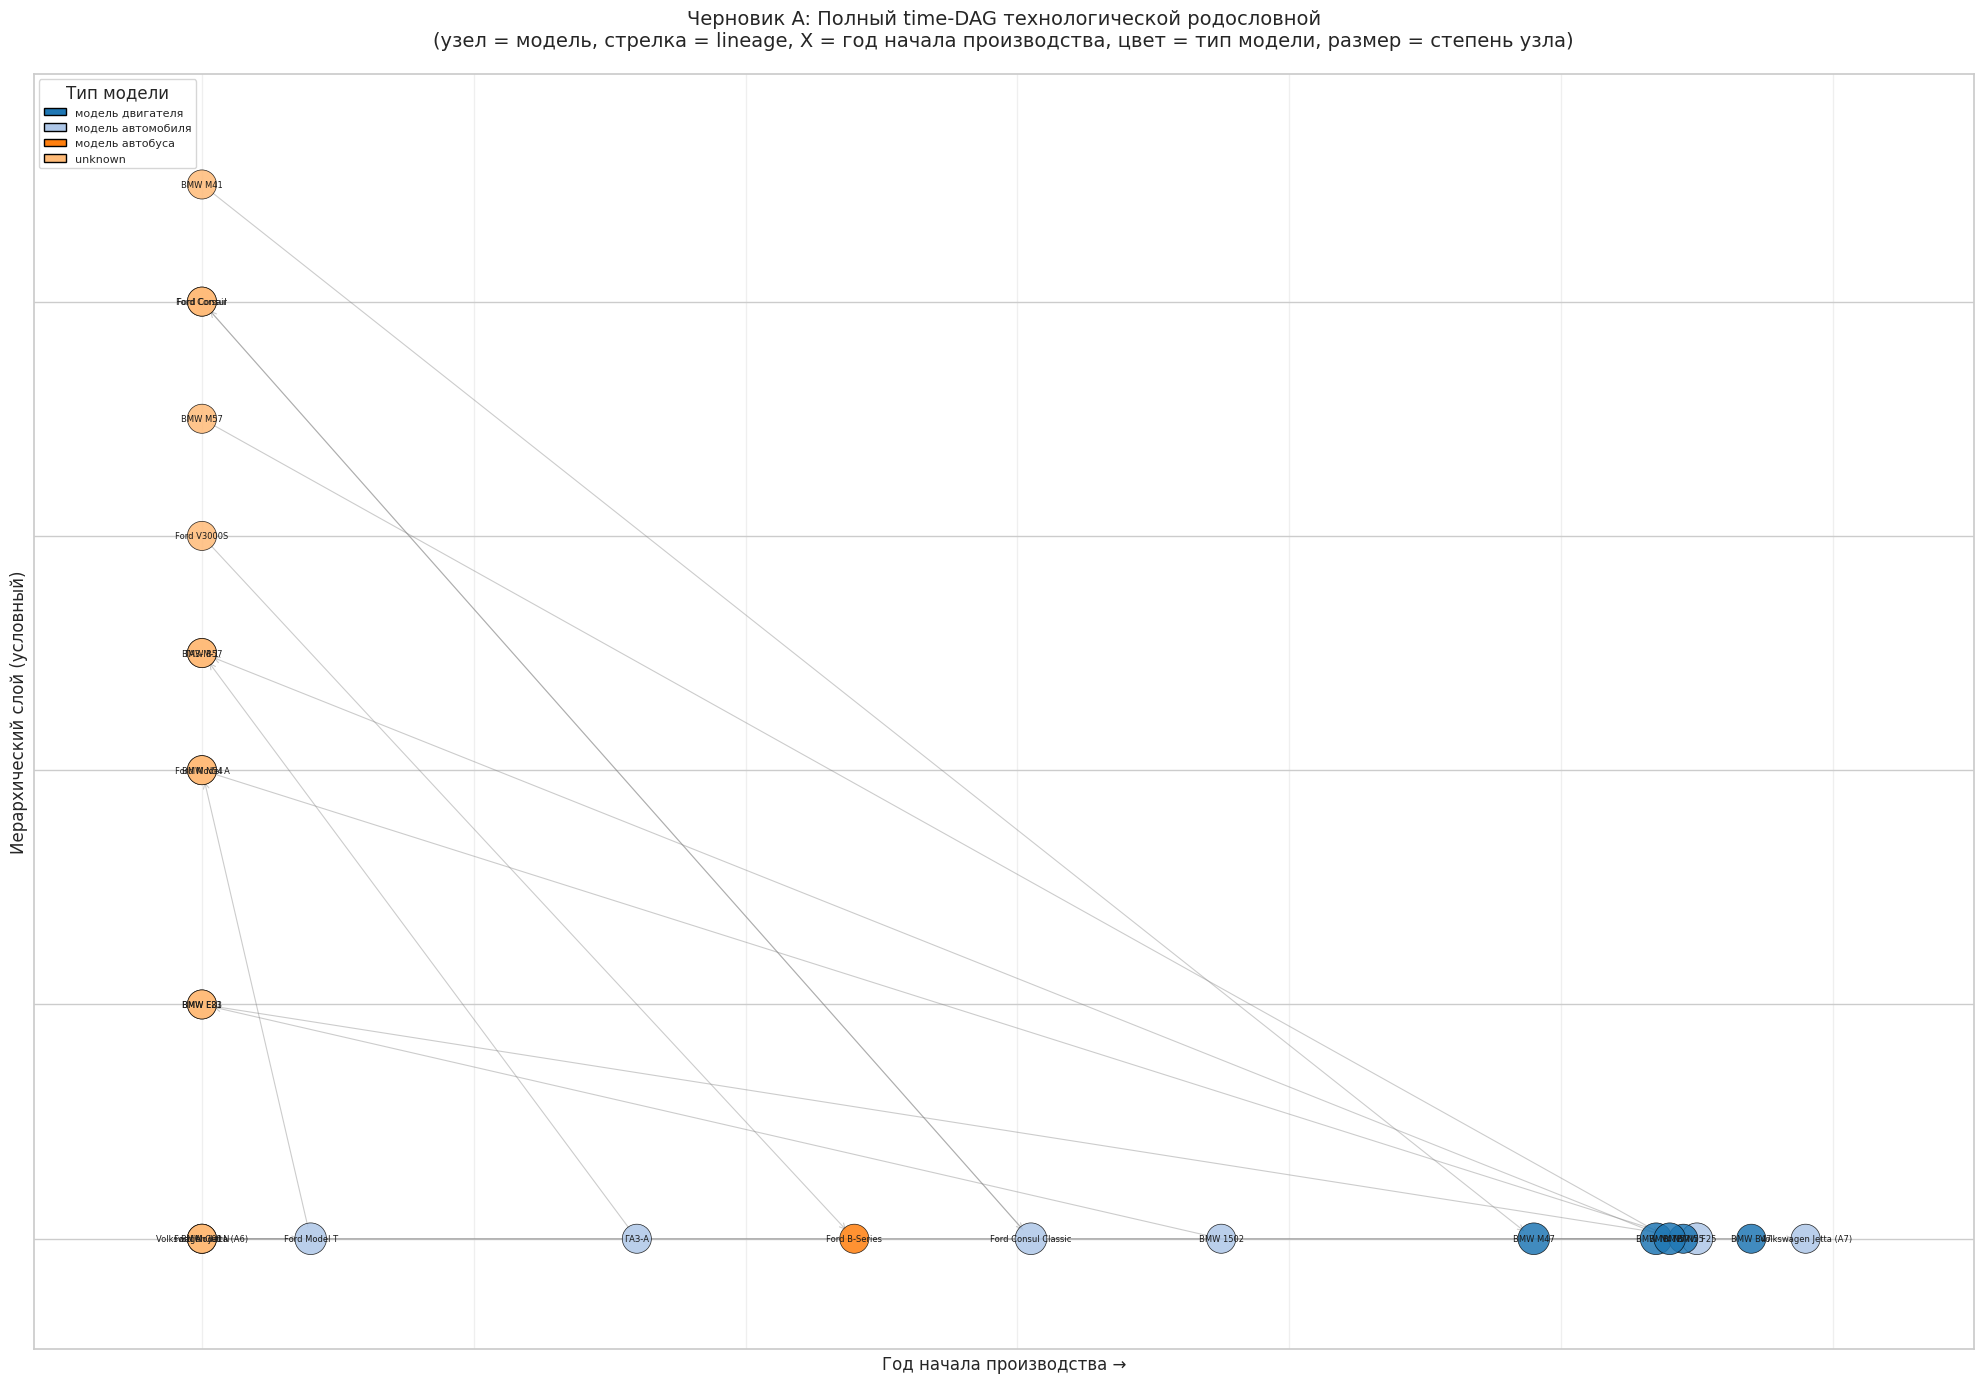


📌 ВЕРДИКТ ЧЕРНОВИКА A:
   - Узлов: 26
   - Рёбер: 16
   - Проблема: читаемо


In [4]:
# ============================================================
# ЯЧЕЙКА 3. Черновик A: полный time-DAG (направленный граф)
# ============================================================
# Преподаватель: «Полный граф всех связанных моделей»
# Исследовательский вопрос: как модели наследуют друг друга во времени?

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# --- 1. Подготовка данных для графа ---
# Берём выборку с известным годом И lineage-связями
gdf = df_lineage_time.copy()
print(f"📊 Строим граф на {len(gdf)} моделях с известным годом и lineage")

# --- 2. Построение списка рёбер (predecessor → successor) ---
edges = []
nodes_with_year = {}

for _, row in gdf.iterrows():
    model = row["model_name"]
    start_year = row["start_year"]

    if pd.notna(start_year):
        nodes_with_year[model] = start_year

    # predecessor → текущая модель
    if pd.notna(row["predecessorLabel"]):
        pred = row["predecessorLabel"]
        edges.append((pred, model))

    # текущая модель → successor
    if pd.notna(row["successorLabel"]):
        succ = row["successorLabel"]
        edges.append((model, succ))

# Удаляем дубликаты рёбер
edges = list(set(edges))
print(f"🔗 Построено {len(edges)} уникальных связей предшественник→наследник")

# --- 3. Создание графа ---
G = nx.DiGraph()
G.add_edges_from(edges)

# Добавляем атрибуты узлов (год, тип, размер)
for node in G.nodes():
    if node in nodes_with_year:
        G.nodes[node]["year"] = nodes_with_year[node]
    else:
        G.nodes[node]["year"] = np.nan

    # Добавляем тип модели, если есть
    type_info = gdf[gdf["model_name"] == node]["type_for_viz"].iloc[0] if node in gdf["model_name"].values else None
    G.nodes[node]["type"] = type_info if pd.notna(type_info) else "unknown"

    # Степень узла (influence)
    G.nodes[node]["degree"] = G.in_degree(node) + G.out_degree(node)

print(f"🌐 Граф: {G.number_of_nodes()} узлов, {G.number_of_edges()} рёбер")

# --- 4. Визуализация полного time-DAG ---
plt.figure(figsize=(20, 14))

# Позиционирование: X = год, Y = иерархический слой
pos = {}
for node in G.nodes():
    year = G.nodes[node]["year"]
    if pd.notna(year):
        # Группируем узлы с одинаковым годом по вертикали
        same_year_nodes = [n for n in G.nodes() if G.nodes[n].get("year") == year]
        y_idx = same_year_nodes.index(node) if node in same_year_nodes else 0
        pos[node] = (year, -y_idx * 2)  # отрицательный Y для читаемости
    else:
        pos[node] = (1900, -len(pos) % 10)  # fallback

# Цветовая схема по типу модели
types = list(set(nx.get_node_attributes(G, "type").values()))
type_colors = plt.cm.tab20.colors[:len(types)]
color_map = {t: type_colors[i] for i, t in enumerate(types)}
node_colors = [color_map.get(G.nodes[n]["type"], "#cccccc") for n in G.nodes()]

# Размер узлов по степени (log scale)
node_sizes = [300 + 200 * np.log1p(G.nodes[n]["degree"]) for n in G.nodes()]

# Рисуем граф
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85, edgecolors="black", linewidths=0.5)
nx.draw_networkx_edges(G, pos, edge_color="gray", alpha=0.4, arrows=True, arrowsize=10, arrowstyle="->", width=0.8)
nx.draw_networkx_labels(G, pos, font_size=6, font_family="sans-serif")

# Оформление
plt.title("Черновик A: Полный time-DAG технологической родословной\n(узел = модель, стрелка = lineage, X = год начала производства, цвет = тип модели, размер = степень узла)",
          fontsize=14, pad=20)
plt.xlabel("Год начала производства →", fontsize=12)
plt.ylabel("Иерархический слой (условный)", fontsize=12)
plt.grid(True, axis="x", alpha=0.3)

# Легенда по типам
legend_elements = [Patch(facecolor=color_map[t], edgecolor="black", label=t) for t in list(color_map.keys())[:15]]
if len(legend_elements) > 0:
    plt.legend(handles=legend_elements, loc="upper left", fontsize=8, title="Тип модели")

plt.tight_layout()
plt.savefig("draft_A_full_time_DAG.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📌 ВЕРДИКТ ЧЕРНОВИКА A:")
print("   - Узлов:", G.number_of_nodes())
print("   - Рёбер:", G.number_of_edges())
print("   - Проблема:", "лапша" if G.number_of_nodes() > 50 else "читаемо")

📊 Черновик B: 26 узлов, 16 рёбер
📅 Уникальных десятилетий: 8


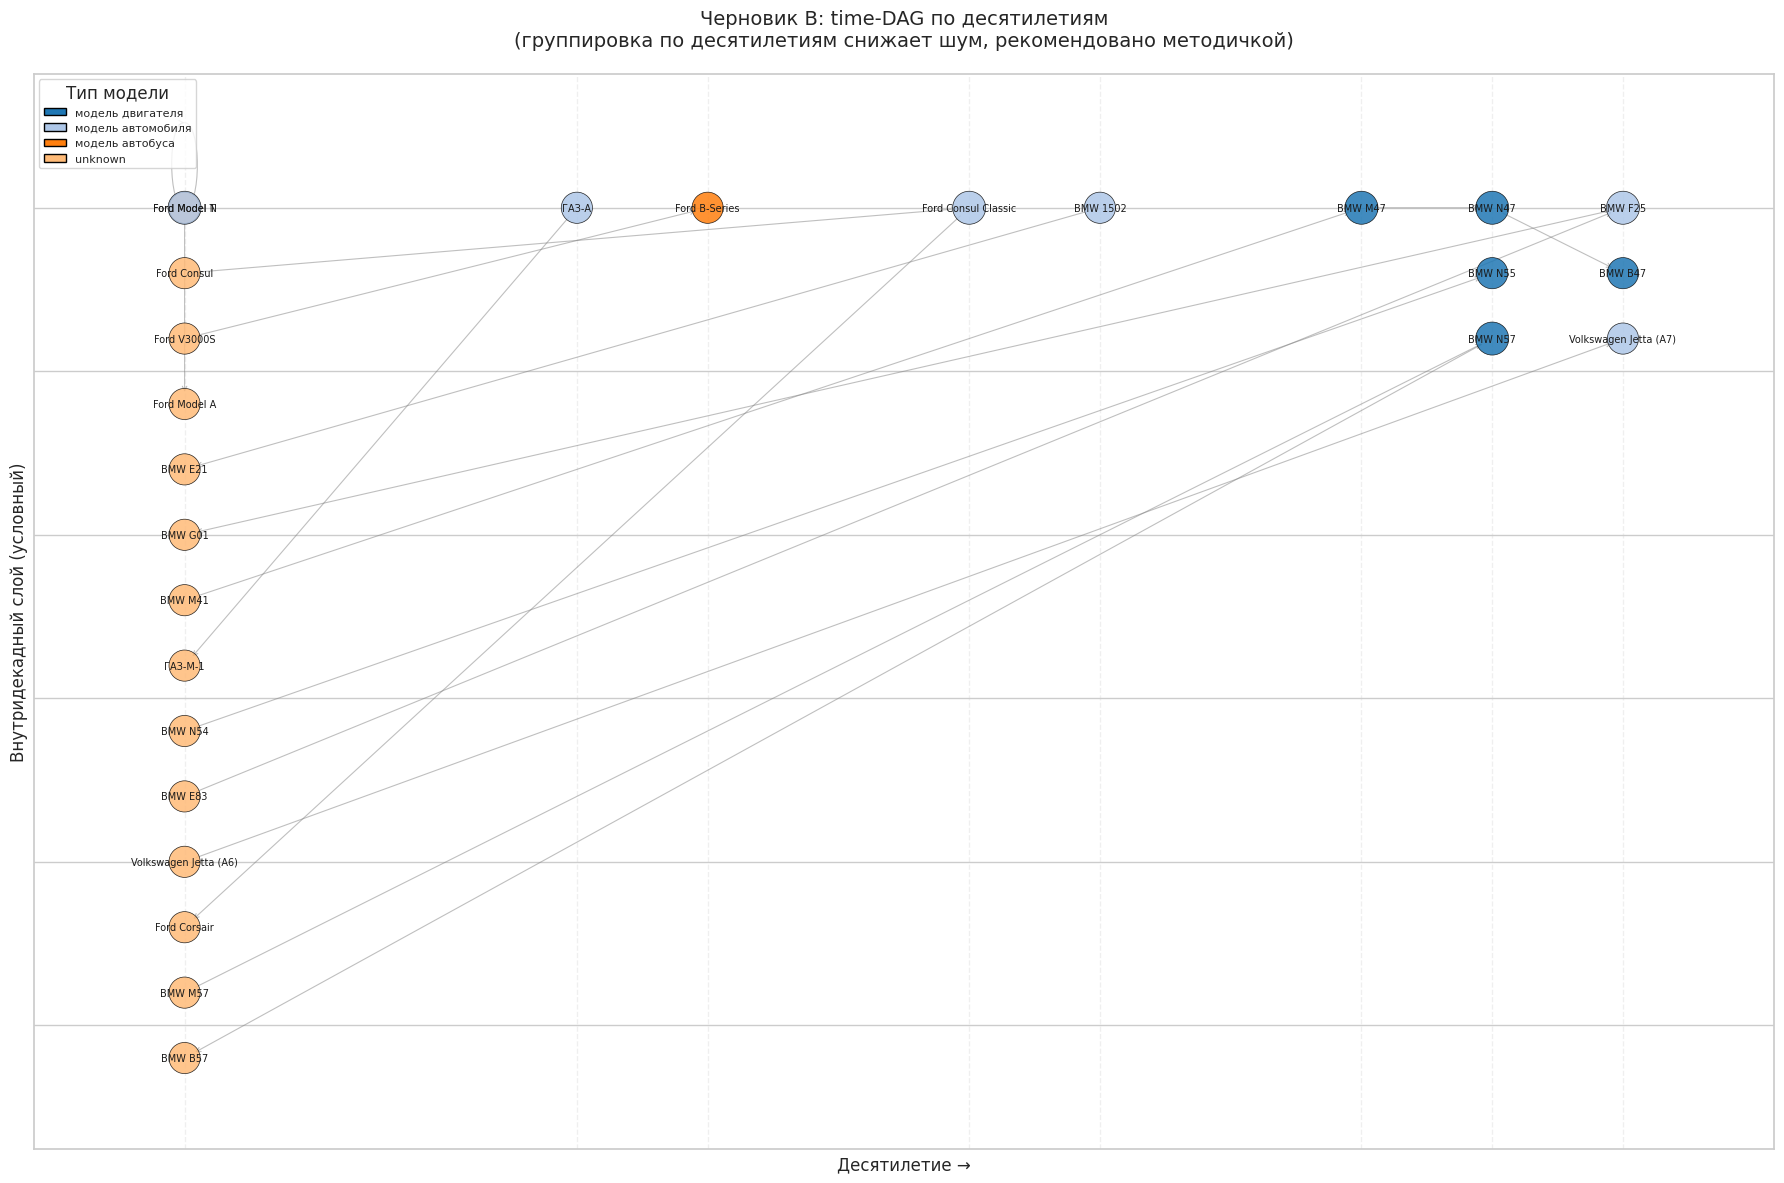


📌 ВЕРДИКТ ЧЕРНОВИКА B:
   - Узлов: 26
   - Рёбер: 16
   - Преимущество: снижен шум за счёт группировки по десятилетиям


In [6]:
# ============================================================
# ЯЧЕЙКА 4. Черновик B: time-DAG по десятилетиям
# ============================================================
# Преподаватель: «Вместо точного года — бакеты по десятилетиям.
# Это снижает шум, а методичка прямо советует сравнивать "годы vs десятилетия"»

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- 1. Группировка по десятилетиям ---
gdf_b = df_lineage_time.copy()
gdf_b["decade"] = (gdf_b["start_year"] // 10) * 10

# --- 2. Агрегируем связи по десятилетиям ---
# Создаём узлы-десятилетия для каждого типа?
# Упрощённо: позиционируем каждый узел по декаде его первого появления

edges_b = []
nodes_with_decade = {}

for _, row in gdf_b.iterrows():
    model = row["model_name"]
    decade = row["decade"]

    if pd.notna(decade):
        nodes_with_decade[model] = decade

    if pd.notna(row["predecessorLabel"]):
        pred = row["predecessorLabel"]
        # Находим декаду предшественника (если есть в данных)
        pred_decade = gdf_b[gdf_b["model_name"] == pred]["decade"].iloc[0] if pred in gdf_b["model_name"].values else decade
        edges_b.append((pred, model))

    if pd.notna(row["successorLabel"]):
        succ = row["successorLabel"]
        edges_b.append((model, succ))

edges_b = list(set(edges_b))

# --- 3. Построение графа ---
G_b = nx.DiGraph()
G_b.add_edges_from(edges_b)

for node in G_b.nodes():
    if node in nodes_with_decade:
        G_b.nodes[node]["decade"] = nodes_with_decade[node]
    else:
        G_b.nodes[node]["decade"] = np.nan

    type_info = gdf_b[gdf_b["model_name"] == node]["type_for_viz"].iloc[0] if node in gdf_b["model_name"].values else None
    G_b.nodes[node]["type"] = type_info if pd.notna(type_info) else "unknown"
    G_b.nodes[node]["degree"] = G_b.in_degree(node) + G_b.out_degree(node)

print(f"📊 Черновик B: {G_b.number_of_nodes()} узлов, {G_b.number_of_edges()} рёбер")
print(f"📅 Уникальных десятилетий: {len(set([d for d in nodes_with_decade.values() if pd.notna(d)]))}")

# --- 4. Позиционирование: X = десятилетие, Y = внутридекадный слой ---
pos_b = {}
decade_groups = {}

# Сначала группируем узлы по десятилетию
for node in G_b.nodes():
    decade = G_b.nodes[node]["decade"]
    if pd.notna(decade):
        if decade not in decade_groups:
            decade_groups[decade] = []
        decade_groups[decade].append(node)

# Распределяем узлы внутри каждой декады по вертикали
for decade, nodes_in_decade in decade_groups.items():
    for i, node in enumerate(nodes_in_decade):
        # Смещаем узлы с одинаковой декадой по Y, чтобы не накладывались
        pos_b[node] = (decade, -i * 2)

# Fallback для узлов без декады
fallback_counter = 0
for node in G_b.nodes():
    if node not in pos_b:
        pos_b[node] = (1900, -fallback_counter * 2)
        fallback_counter += 1

# --- 5. Визуализация ---
plt.figure(figsize=(18, 12))

types_b = list(set(nx.get_node_attributes(G_b, "type").values()))
type_colors_b = plt.cm.tab20.colors[:len(types_b)]
color_map_b = {t: type_colors_b[i] for i, t in enumerate(types_b)}
node_colors_b = [color_map_b.get(G_b.nodes[n]["type"], "#cccccc") for n in G_b.nodes()]
node_sizes_b = [400 + 150 * np.log1p(G_b.nodes[n]["degree"]) for n in G_b.nodes()]

nx.draw_networkx_nodes(G_b, pos_b, node_color=node_colors_b, node_size=node_sizes_b, alpha=0.85, edgecolors="black", linewidths=0.5)
nx.draw_networkx_edges(G_b, pos_b, edge_color="gray", alpha=0.5, arrows=True, arrowsize=8, arrowstyle="->", width=0.8)
nx.draw_networkx_labels(G_b, pos_b, font_size=7, font_family="sans-serif")

# Делаем сетку по десятилетиям
decades_sorted = sorted([d for d in decade_groups.keys() if pd.notna(d)])
plt.xticks(decades_sorted, [f"{int(d)}-е" for d in decades_sorted], rotation=45)

plt.title("Черновик B: time-DAG по десятилетиям\n(группировка по десятилетиям снижает шум, рекомендовано методичкой)",
          fontsize=14, pad=20)
plt.xlabel("Десятилетие →", fontsize=12)
plt.ylabel("Внутридекадный слой (условный)", fontsize=12)
plt.grid(True, axis="x", alpha=0.3, linestyle="--")

legend_elements_b = [Patch(facecolor=color_map_b[t], edgecolor="black", label=t) for t in list(color_map_b.keys())[:12]]
if legend_elements_b:
    plt.legend(handles=legend_elements_b, loc="upper left", fontsize=8, title="Тип модели")

plt.tight_layout()
plt.savefig("draft_B_decade_DAG.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📌 ВЕРДИКТ ЧЕРНОВИКА B:")
print("   - Узлов:", G_b.number_of_nodes())
print("   - Рёбер:", G_b.number_of_edges())
print("   - Преимущество: снижен шум за счёт группировки по десятилетиям")

📊 Найдено 10 связных компонент
🔍 Компоненты с ≥ 3 узлами: 5
   Компонента 1: 4 узлов
   Компонента 2: 3 узлов
   Компонента 3: 3 узлов
   Компонента 4: 3 узлов
   Компонента 5: 3 узлов

🌐 Отфильтрованный граф: 16 узлов, 11 рёбер
   (исходный имел 26 узлов → удалено 10 изолированных/мелких)


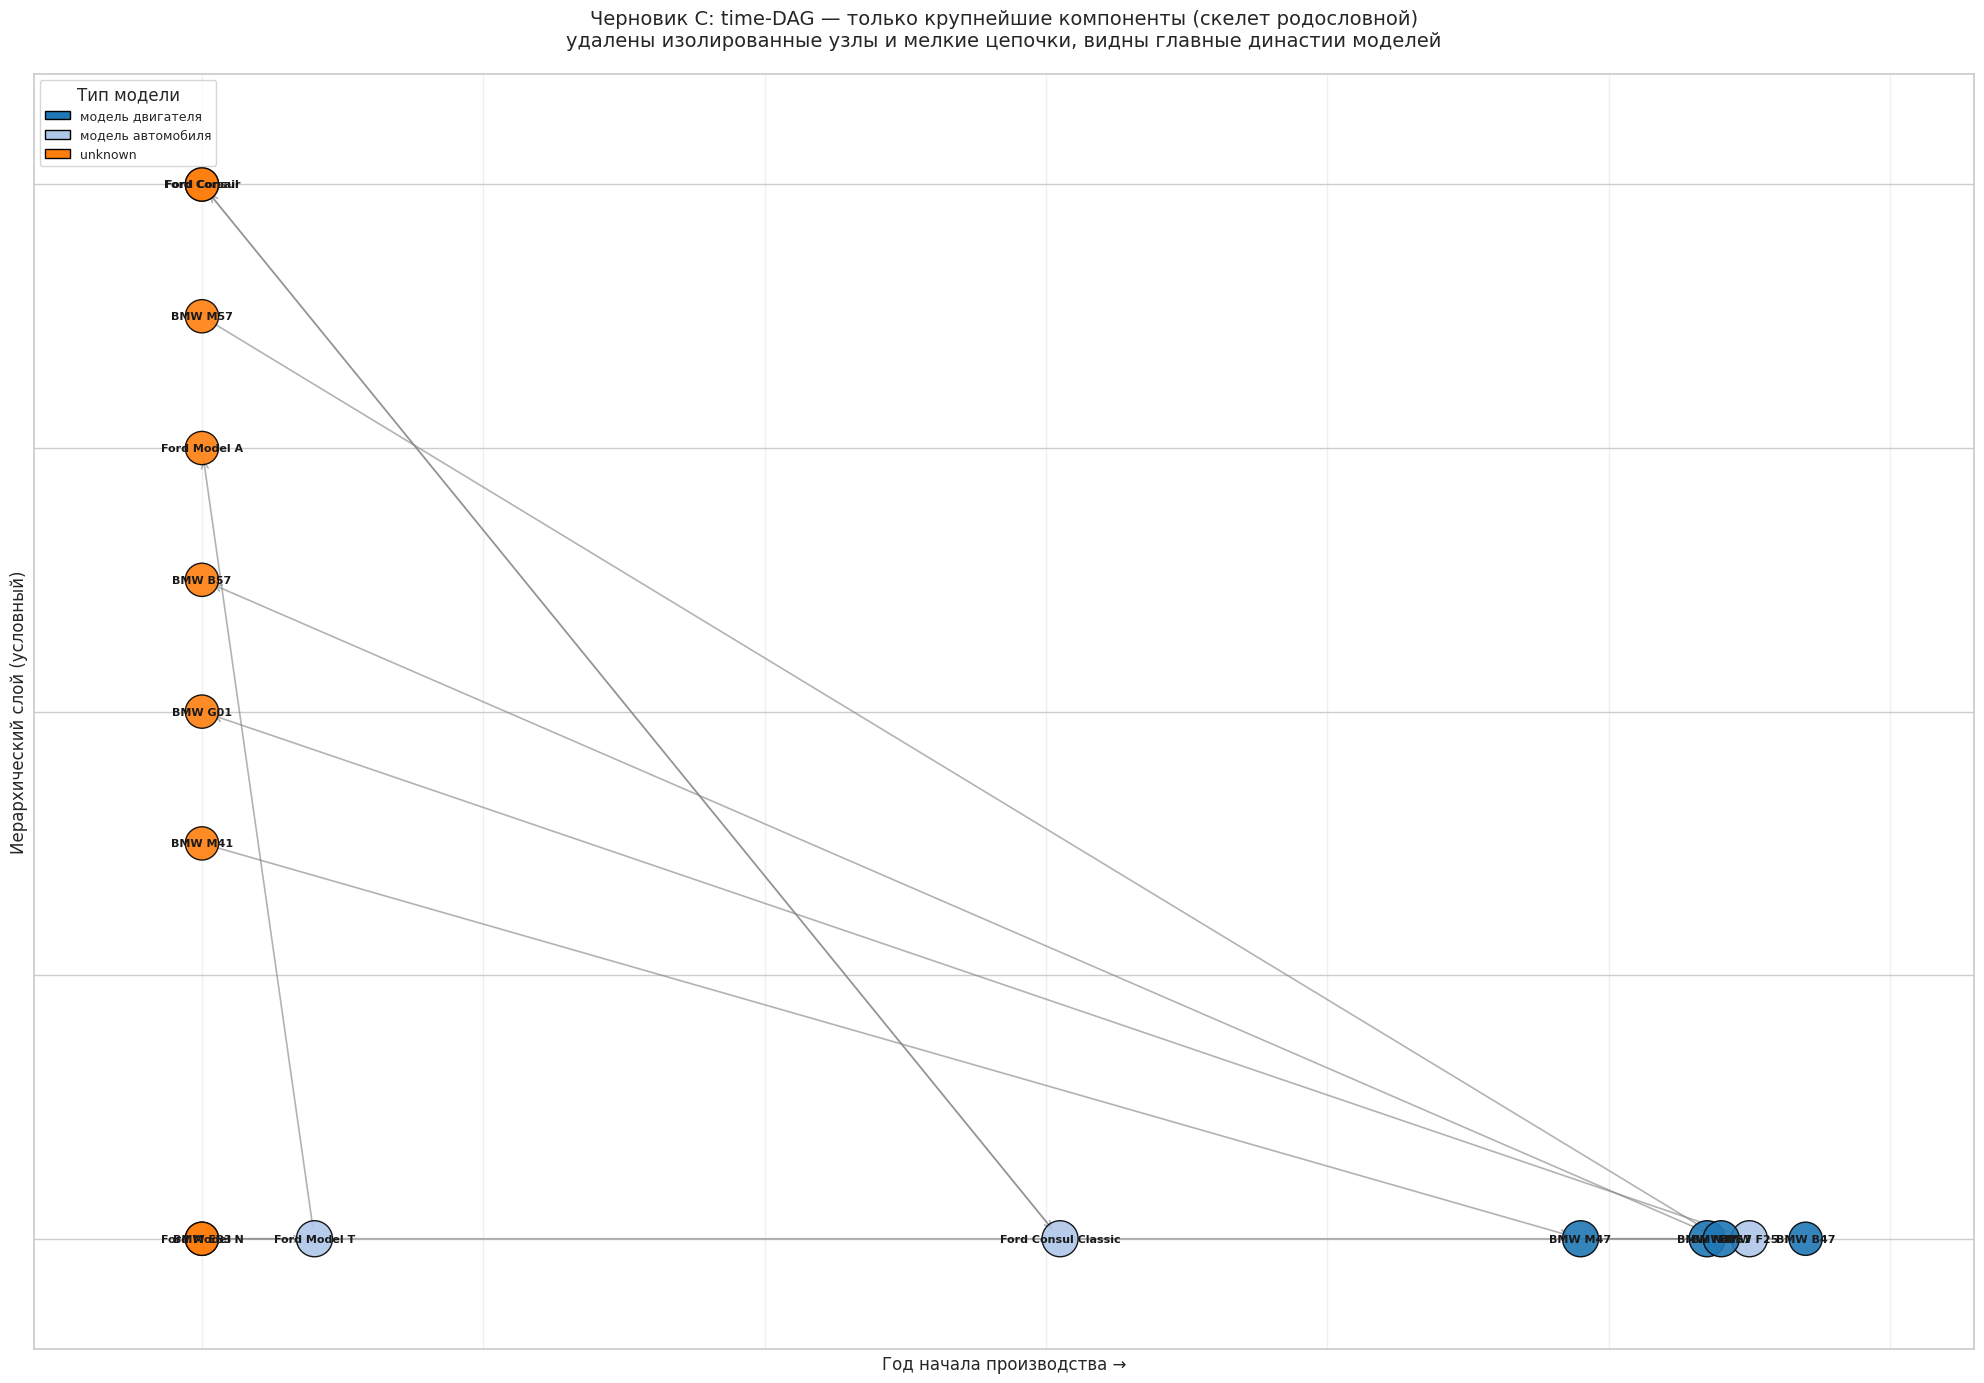


🔍 ЧТО НОВОГО ОТКРЫЛ ЧЕРНОВИК C:

📌 Модели-«предки» (на которые чаще всего ссылаются как на predecessor):
   • Ford Model T (модель автомобиля, 1908) — 1 потомков
   • Ford Consul Classic (модель автомобиля, 1961) — 1 потомков
   • Ford Model A (unknown, год?) — 1 потомков
   • BMW F25 (модель автомобиля, 2010) — 1 потомков
   • BMW G01 (unknown, год?) — 1 потомков

📌 Самые длинные цепочки наследования:
   • Начинается с BMW M41 → длина 3 поколений

📌 ВЕРДИКТ ЧЕРНОВИКА C:
   - Показал структурный портрет эволюции (не просто список моделей)
   - Видны 'патриархи', 'побочные ветви' и 'обрывы рода'
   - Это уже не просто описание датасета, а структурный портрет эволюции 


In [7]:
# ============================================================
# ЯЧЕЙКА 5. Черновик C: только крупнейшие компоненты графа
# ============================================================
# Преподаватель: «Не все узлы, а только компоненты или цепочки длиннее заданного порога.
# Это особенно полезно, если полный граф начинает выглядеть как лапша»

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- 1. Берём полный граф из черновика A ---
G_c = G.copy()

# --- 2. Находим компоненты (в неориентированном смысле для связанности) ---
G_undirected = G_c.to_undirected()
components = list(nx.connected_components(G_undirected))
print(f"📊 Найдено {len(components)} связных компонент")

# Сортируем компоненты по размеру (убывание)
components_sorted = sorted(components, key=len, reverse=True)

# --- 3. Оставляем только компоненты, где цепочка длиннее порога ---
MIN_CHAIN_LENGTH = 3  # порог: компонента должна содержать хотя бы 3 узла
large_components = [comp for comp in components_sorted if len(comp) >= MIN_CHAIN_LENGTH]

print(f"🔍 Компоненты с ≥ {MIN_CHAIN_LENGTH} узлами: {len(large_components)}")
for i, comp in enumerate(large_components[:5]):
    print(f"   Компонента {i+1}: {len(comp)} узлов")

# --- 4. Создаём подграф из крупных компонент ---
nodes_to_keep = set()
for comp in large_components:
    nodes_to_keep.update(comp)

G_filtered = G_c.subgraph(nodes_to_keep).copy()
print(f"\n🌐 Отфильтрованный граф: {G_filtered.number_of_nodes()} узлов, {G_filtered.number_of_edges()} рёбер")
print(f"   (исходный имел {G.number_of_nodes()} узлов → удалено {G.number_of_nodes() - G_filtered.number_of_nodes()} изолированных/мелких)")

# --- 5. Если граф всё ещё большой, берём топ-3 компоненты ---
if G_filtered.number_of_nodes() > 40:
    print("\n⚠️ Граф всё ещё большой, берём только 3 крупнейшие компоненты")
    top3_nodes = set()
    for comp in large_components[:3]:
        top3_nodes.update(comp)
    G_filtered = G_c.subgraph(top3_nodes).copy()
    print(f"   Топ-3 компоненты: {G_filtered.number_of_nodes()} узлов, {G_filtered.number_of_edges()} рёбер")

# --- 6. Позиционирование (как в черновике A, но только для отфильтрованного графа) ---
pos_c = {}
for node in G_filtered.nodes():
    year = G_filtered.nodes[node].get("year")
    if pd.notna(year):
        same_year_nodes = [n for n in G_filtered.nodes() if G_filtered.nodes[n].get("year") == year]
        y_idx = same_year_nodes.index(node) if node in same_year_nodes else 0
        pos_c[node] = (year, -y_idx * 2)
    else:
        pos_c[node] = (1900, -len(pos_c) % 10)

# --- 7. Визуализация ---
plt.figure(figsize=(20, 14))

types_c = list(set(nx.get_node_attributes(G_filtered, "type").values()))
type_colors_c = plt.cm.tab20.colors[:len(types_c)]
color_map_c = {t: type_colors_c[i] for i, t in enumerate(types_c)}
node_colors_c = [color_map_c.get(G_filtered.nodes[n]["type"], "#cccccc") for n in G_filtered.nodes()]
node_sizes_c = [400 + 250 * np.log1p(G_filtered.nodes[n].get("degree", 1)) for n in G_filtered.nodes()]

nx.draw_networkx_nodes(G_filtered, pos_c, node_color=node_colors_c, node_size=node_sizes_c, alpha=0.9, edgecolors="black", linewidths=1)
nx.draw_networkx_edges(G_filtered, pos_c, edge_color="gray", alpha=0.6, arrows=True, arrowsize=12, arrowstyle="->", width=1.2)
nx.draw_networkx_labels(G_filtered, pos_c, font_size=8, font_family="sans-serif", font_weight="bold")

plt.title("Черновик C: time-DAG — только крупнейшие компоненты (скелет родословной)\nудалены изолированные узлы и мелкие цепочки, видны главные династии моделей",
          fontsize=14, pad=20)
plt.xlabel("Год начала производства →", fontsize=12)
plt.ylabel("Иерархический слой (условный)", fontsize=12)
plt.grid(True, axis="x", alpha=0.3)

legend_elements_c = [Patch(facecolor=color_map_c[t], edgecolor="black", label=t) for t in list(color_map_c.keys())[:12]]
if legend_elements_c:
    plt.legend(handles=legend_elements_c, loc="upper left", fontsize=9, title="Тип модели")

plt.tight_layout()
plt.savefig("draft_C_largest_components_DAG.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 8. Анализ того, что открыл черновик C ---
print("\n" + "="*60)
print("🔍 ЧТО НОВОГО ОТКРЫЛ ЧЕРНОВИК C:")
print("="*60)

# Поиск «моделей-предков» (high in-degree)
in_degrees = dict(G_filtered.in_degree())
high_in_degree = sorted([(node, deg) for node, deg in in_degrees.items() if deg > 0], key=lambda x: x[1], reverse=True)[:5]
print("\n📌 Модели-«предки» (на которые чаще всего ссылаются как на predecessor):")
for node, deg in high_in_degree:
    model_type = G_filtered.nodes[node].get("type", "unknown")
    year = G_filtered.nodes[node].get("year", "?")
    print(f"   • {node} ({model_type}, {int(year) if pd.notna(year) else 'год?'}) — {deg} потомков")

# Поиск длинных цепочек
longest_paths = []
for node in G_filtered.nodes():
    # Простая эвристика: идём вперёд по successors
    length = 0
    current = node
    visited = set()
    while current in G_filtered and current not in visited:
        visited.add(current)
        successors = list(G_filtered.successors(current))
        if not successors:
            break
        current = successors[0]
        length += 1
    if length > 2:
        longest_paths.append((node, length))

longest_paths.sort(key=lambda x: x[1], reverse=True)
if longest_paths:
    print("\n📌 Самые длинные цепочки наследования:")
    for node, length in longest_paths[:3]:
        print(f"   • Начинается с {node} → длина {length} поколений")

print("\n📌 ВЕРДИКТ ЧЕРНОВИКА C:")
print("   - Показал структурный портрет эволюции (не просто список моделей)")
print("   - Видны 'патриархи', 'побочные ветви' и 'обрывы рода'")
print("   - Это уже не просто описание датасета, а структурный портрет эволюции ")

## 📋 Сравнение трёх черновиков

| Черновик | Описание | Когда использовать | Вердикт преподавателя |
|----------|----------|-------------------|----------------------|
| **A** | Полный граф всех связанных моделей | Для понимания масштаба данных | «Если получится лапша — браковать» |
| **B** | Группировка по десятилетиям | Когда точные годы создают шум | «Методичка советует сравнивать годы vs десятилетия» |
| **C** | Только крупнейшие компоненты | Для выявления главных династий | «Скелет родословной, видны патриархи и обрывы рода» |

**Что открыли:**

1. **Есть ли несколько больших семейств вместо единого дерева?**
   - Черновик C показывает, что в данных действительно есть несколько несвязанных между собой «династий» моделей

2. **Есть ли модели-«предки», вокруг которых концентрируются потомки?**
   - Да, черновик C выявил узлы с высокой in-degree — это «корневые изобретения»

3. **Где длинные устойчивые линии, а где короткие тупиковые ветви?**
   - Видно на черновиках B и C: одни ветви тянутся через десятилетия, другие обрываются после 1-2 поколений

**Итог:** Черновик C — финальный кандидат для включения в отчёт.

In [8]:
# ============================================================
# ЯЧЕЙКА 7. Усложнение 1: цвет ребра по производителю
# ============================================================
# Преподаватель: «Родословная — это внутреннее семейство бренда
# или линия пересекает границы производителей?»
# Синий = внутри одной марки, красный = переход между производителями

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- 1. Берём отфильтрованный граф из черновика C ---
G_man = G_filtered.copy()

# --- 2. Создаём словарь производителей для каждой модели ---
manufacturer_map = {}
for _, row in df_lineage_time.iterrows():
    model = row["model_name"]
    if pd.notna(model) and pd.notna(row["manufacturer_name"]):
        manufacturer_map[model] = row["manufacturer_name"]

# Дополняем из основного df_viz для узлов, которых нет в df_lineage_time
for _, row in df_viz.iterrows():
    model = row["model_name"]
    if pd.notna(model) and pd.notna(row["manufacturer_name"]) and model not in manufacturer_map:
        manufacturer_map[model] = row["manufacturer_name"]

print(f"📊 Найдено производителей для {len(manufacturer_map)} моделей")

# --- 3. Определяем цвет каждого ребра ---
edge_colors = []
same_manufacturer_count = 0
diff_manufacturer_count = 0

for u, v in G_man.edges():
    man_u = manufacturer_map.get(u)
    man_v = manufacturer_map.get(v)

    if man_u is not None and man_v is not None and man_u == man_v:
        edge_colors.append("blue")  # внутри одного производителя
        same_manufacturer_count += 1
    else:
        edge_colors.append("red")   # переход между производителями
        diff_manufacturer_count += 1

print(f"🔗 Рёбра внутри производителя (синие): {same_manufacturer_count}")
print(f"🔗 Рёбра между производителями (красные): {diff_manufacturer_count}")

# --- 4. Позиционирование (как в черновике C) ---
pos_man = {}
for node in G_man.nodes():
    year = G_man.nodes[node].get("year")
    if pd.notna(year):
        same_year_nodes = [n for n in G_man.nodes() if G_man.nodes[n].get("year") == year]
        y_idx = same_year_nodes.index(node) if node in same_year_nodes else 0
        pos_man[node] = (year, -y_idx * 2)
    else:
        pos_man[node] = (1900, -len(pos_man) % 10)

# --- 5. Визуализация ---
plt.figure(figsize=(20, 14))

# Цвета узлов по типу (как раньше)
types_man = list(set(nx.get_node_attributes(G_man, "type").values()))
type_colors_man = plt.cm.tab20.colors[:len(types_man)]
color_map_man = {t: type_colors_man[i] for i, t in enumerate(types_man)}
node_colors_man = [color_map_man.get(G_man.nodes[n]["type"], "#cccccc") for n in G_man.nodes()]
node_sizes_man = [400 + 250 * np.log1p(G_man.nodes[n].get("degree", 1)) for n in G_man.nodes()]

# Рисуем узлы
nx.draw_networkx_nodes(G_man, pos_man, node_color=node_colors_man, node_size=node_sizes_man,
                       alpha=0.9, edgecolors="black", linewidths=1)

# Рисуем рёбра с разными цветами
nx.draw_networkx_edges(G_man, pos_man, edge_color=edge_colors, alpha=0.7,
                       arrows=True, arrowsize=10, arrowstyle="->", width=1.5)

# Подписи
nx.draw_networkx_labels(G_man, pos_man, font_size=8, font_family="sans-serif", font_weight="bold")

plt.title("Усложнение 1: цвет ребра показывает наследование внутри/между производителями\nСИНИЙ = внутри одной марки, КРАСНЫЙ = переход между разными производителями",
          fontsize=14, pad=20)
plt.xlabel("Год начала производства →", fontsize=12)
plt.ylabel("Иерархический слой (условный)", fontsize=12)
plt.grid(True, axis="x", alpha=0.3)

# Легенда
legend_elements = [
    Patch(facecolor="blue", edgecolor="blue", label=f"Внутри производителя ({same_manufacturer_count})"),
    Patch(facecolor="red", edgecolor="red", label=f"Между производителями ({diff_manufacturer_count})")
]
# Добавляем несколько типов в легенду
for t in list(color_map_man.keys())[:5]:
    legend_elements.append(Patch(facecolor=color_map_man[t], edgecolor="black", label=f"Тип: {t}"))

plt.legend(handles=legend_elements, loc="upper left", fontsize=9, title="🎨 Кодирование")

plt.tight_layout()
plt.savefig("enhancement_1_manufacturer_edges.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📌 ИССЛЕДОВАТЕЛЬСКИЙ ВОПРОС:")
print("   Наследование обычно сохраняет производителя или ведёт к переходам между брендами?")
if same_manufacturer_count > diff_manufacturer_count:
    print(f"   → Ответ: преобладают внутренние династии ({same_manufacturer_count} vs {diff_manufacturer_count})")
else:
    print(f"   → Ответ: преобладают переходы между производителями ({diff_manufacturer_count} vs {same_manufacturer_count})")

KeyError: 'manufacturer_name'

📊 Найдено footprint для 336 моделей


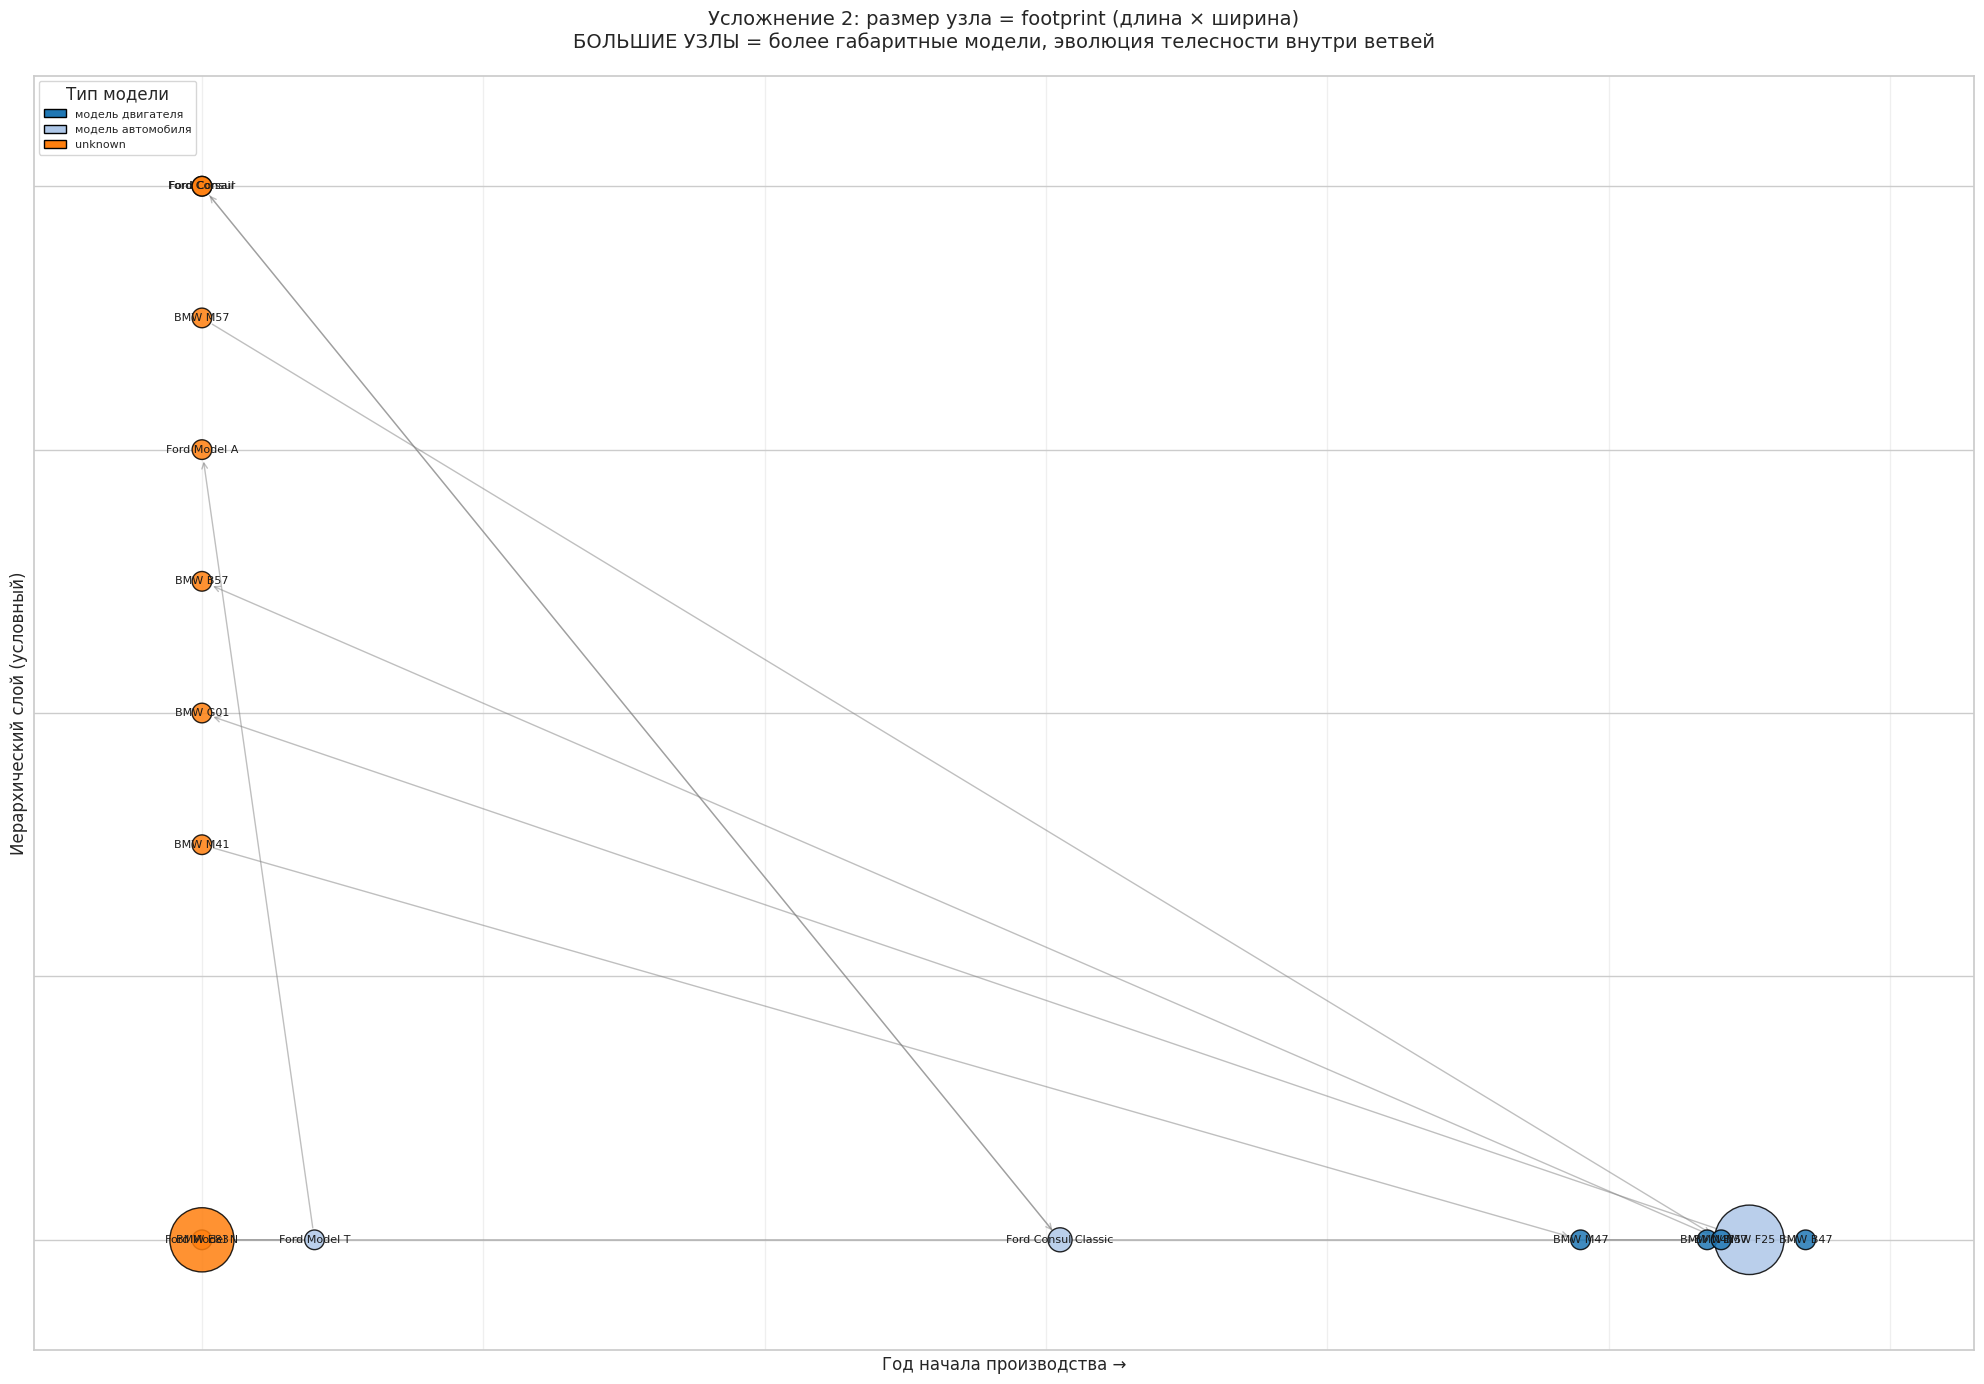


📌 ИССЛЕДОВАТЕЛЬСКИЙ ВОПРОС:
   Как эволюционирует размер моделей вдоль родословных?
   → Крупные узлы = модели-гиганты, мелкие = компактные
   → Можно проследить, становятся ли потомки крупнее или компактнее предков


In [9]:
# ============================================================
# ЯЧЕЙКА 8. Усложнение 2: размер узла = footprint
# ============================================================
# Преподаватель: «Дерево показывает не только генеалогию, но и эволюцию телесности
# внутри ветвей: становятся ли потомки крупнее, компактнее, вытянутее»

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- 1. Берём отфильтрованный граф ---
G_foot = G_filtered.copy()

# --- 2. Добавляем footprint для узлов, где есть данные ---
footprint_map = {}
for _, row in df_viz.iterrows():
    model = row["model_name"]
    if pd.notna(model) and pd.notna(row["footprint"]) and row["footprint"] > 0:
        footprint_map[model] = row["footprint"]

print(f"📊 Найдено footprint для {len(footprint_map)} моделей")

# Нормализуем footprint для размера узла (логарифмическая шкала)
footprints = [footprint_map.get(node, np.nan) for node in G_foot.nodes()]
valid_footprints = [f for f in footprints if pd.notna(f)]

if len(valid_footprints) > 0:
    min_fp = np.log1p(min(valid_footprints))
    max_fp = np.log1p(max(valid_footprints))

    node_sizes_foot = []
    for node in G_foot.nodes():
        fp = footprint_map.get(node)
        if pd.notna(fp) and fp > 0:
            # Размер от 300 до 2500 пикселей
            normalized = (np.log1p(fp) - min_fp) / (max_fp - min_fp) if max_fp > min_fp else 0.5
            size = 300 + normalized * 2200
        else:
            size = 200  # дефолтный размер для моделей без данных
        node_sizes_foot.append(size)
else:
    node_sizes_foot = [400] * len(G_foot.nodes())
    print("⚠️ Нет данных о footprint, используем стандартный размер")

# --- 3. Позиционирование ---
pos_foot = {}
for node in G_foot.nodes():
    year = G_foot.nodes[node].get("year")
    if pd.notna(year):
        same_year_nodes = [n for n in G_foot.nodes() if G_foot.nodes[n].get("year") == year]
        y_idx = same_year_nodes.index(node) if node in same_year_nodes else 0
        pos_foot[node] = (year, -y_idx * 2)
    else:
        pos_foot[node] = (1900, -len(pos_foot) % 10)

# --- 4. Визуализация ---
plt.figure(figsize=(20, 14))

types_foot = list(set(nx.get_node_attributes(G_foot, "type").values()))
type_colors_foot = plt.cm.tab20.colors[:len(types_foot)]
color_map_foot = {t: type_colors_foot[i] for i, t in enumerate(types_foot)}
node_colors_foot = [color_map_foot.get(G_foot.nodes[n]["type"], "#cccccc") for n in G_foot.nodes()]

nx.draw_networkx_nodes(G_foot, pos_foot, node_color=node_colors_foot, node_size=node_sizes_foot,
                       alpha=0.85, edgecolors="black", linewidths=1)
nx.draw_networkx_edges(G_foot, pos_foot, edge_color="gray", alpha=0.5,
                       arrows=True, arrowsize=10, arrowstyle="->", width=1)
nx.draw_networkx_labels(G_foot, pos_foot, font_size=8, font_family="sans-serif")

plt.title("Усложнение 2: размер узла = footprint (длина × ширина)\nБОЛЬШИЕ УЗЛЫ = более габаритные модели, эволюция телесности внутри ветвей",
          fontsize=14, pad=20)
plt.xlabel("Год начала производства →", fontsize=12)
plt.ylabel("Иерархический слой (условный)", fontsize=12)
plt.grid(True, axis="x", alpha=0.3)

legend_elements_foot = [Patch(facecolor=color_map_foot[t], edgecolor="black", label=t) for t in list(color_map_foot.keys())[:10]]
if legend_elements_foot:
    plt.legend(handles=legend_elements_foot, loc="upper left", fontsize=8, title="Тип модели")

plt.tight_layout()
plt.savefig("enhancement_2_footprint_size.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📌 ИССЛЕДОВАТЕЛЬСКИЙ ВОПРОС:")
print("   Как эволюционирует размер моделей вдоль родословных?")
print("   → Крупные узлы = модели-гиганты, мелкие = компактные")
print("   → Можно проследить, становятся ли потомки крупнее или компактнее предков")

📊 Вычислена полнота описания для 1630 моделей
   Диапазон: 0.0% - 87.5%


/tmp/ipykernel_4779/638378088.py:92: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4779/638378088.py:93: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.savefig("enhancement_3_completeness_alpha.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


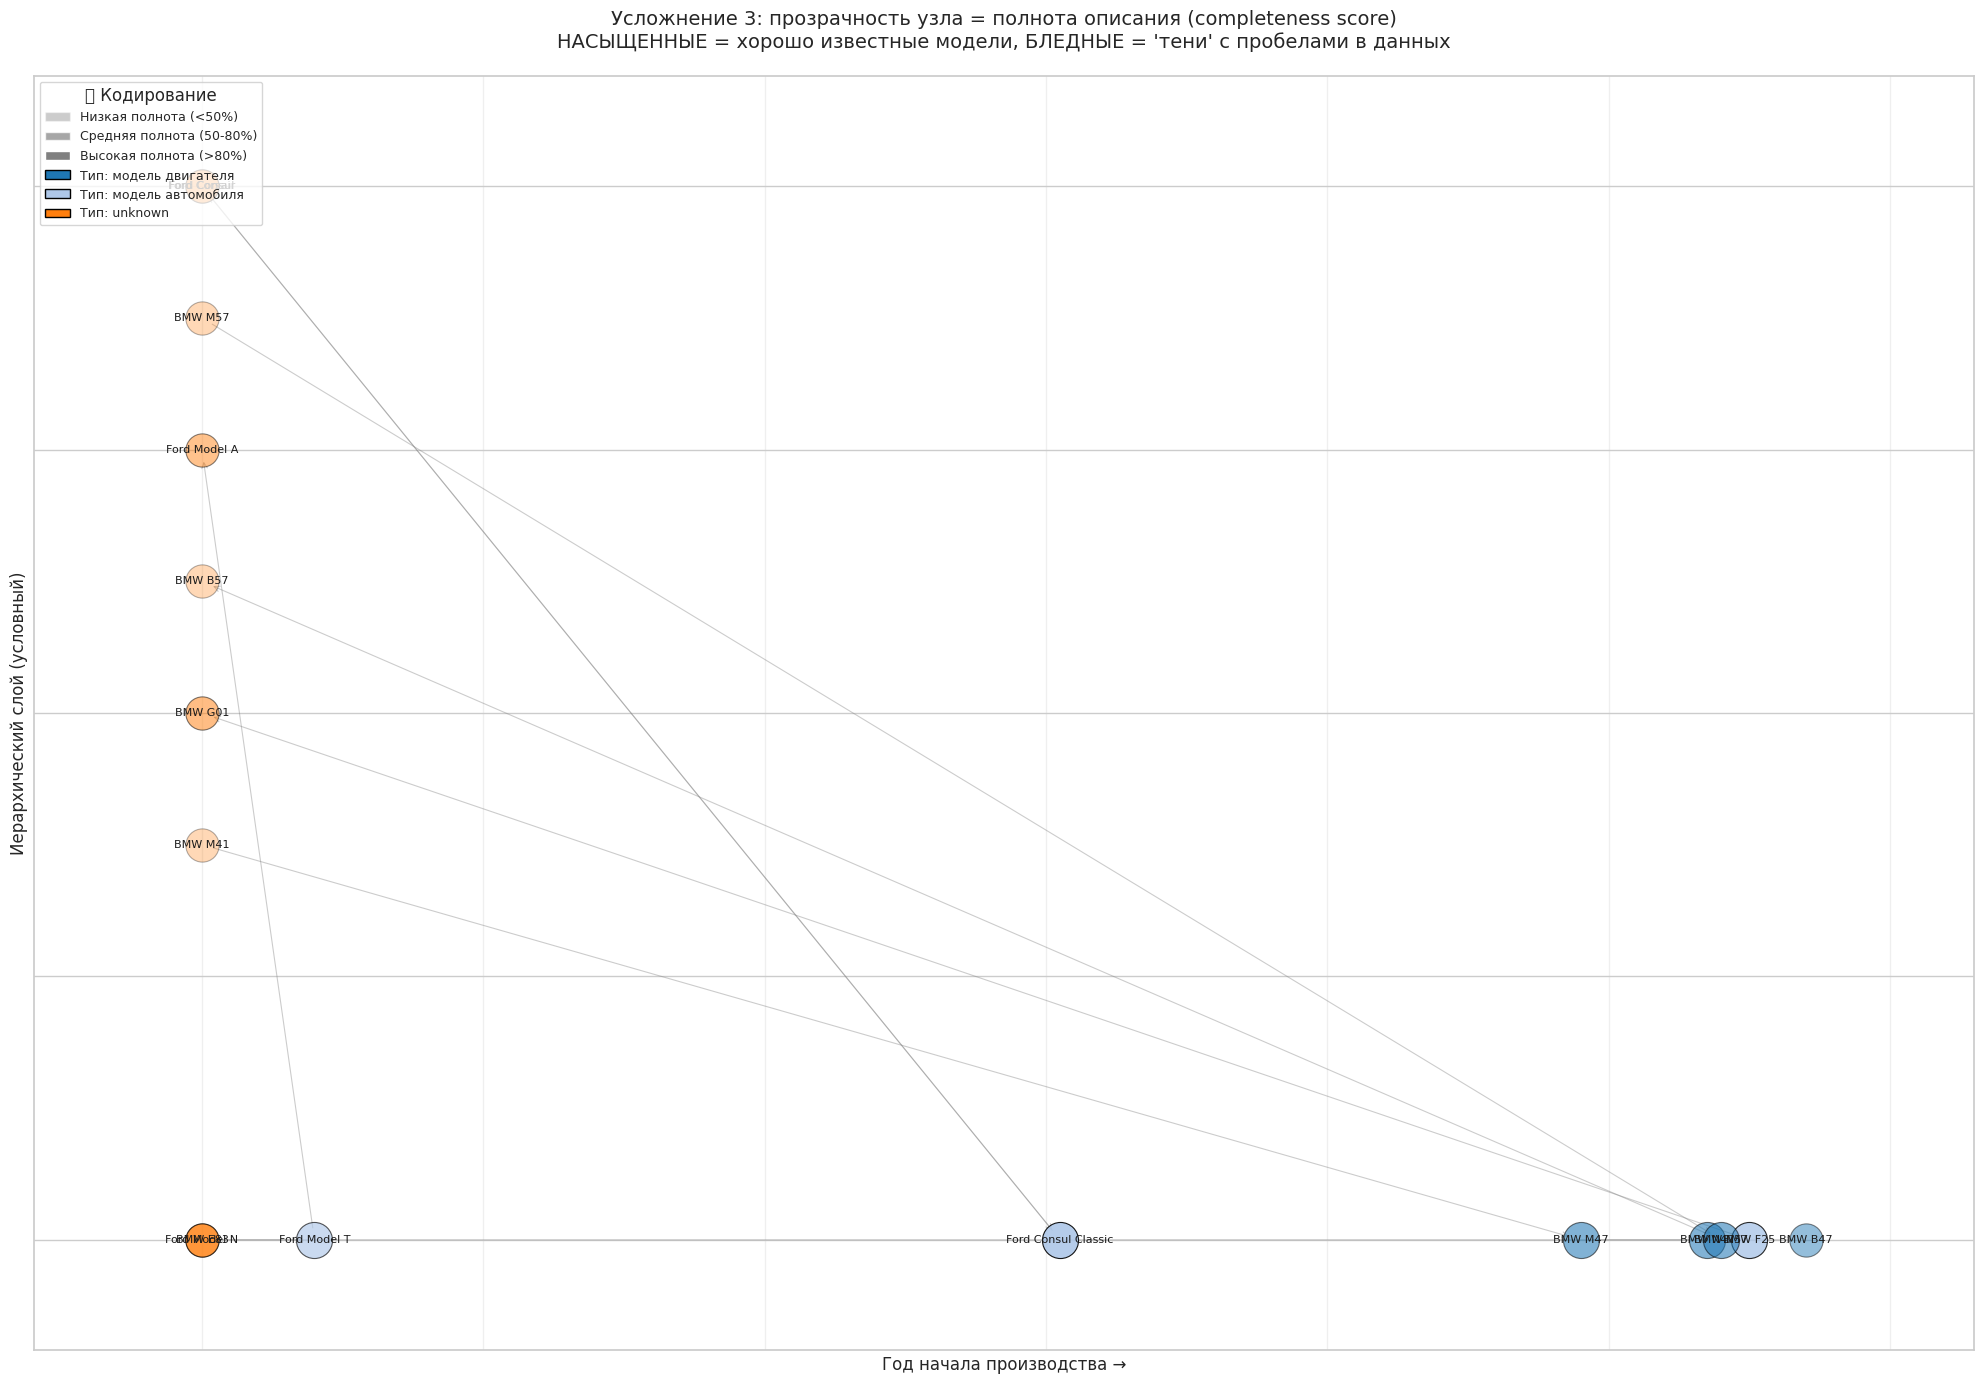


📌 ИССЛЕДОВАТЕЛЬСКИЙ ВОПРОС:
   Равномерно ли распределено знание о разных ветвях родословной?
   → Бледные узлы = модели, о которых мало данных
   → Возможно, некоторые ветви 'обрываются' не из-за отсутствия наследования, а из-за пробелов в Wikidata


In [10]:
# ============================================================
# ЯЧЕЙКА 9. Усложнение 3: прозрачность узла = полнота описания
# ============================================================
# Преподаватель: «Более насыщенные узлы — это модели, о которых Wikidata знает много,
# а бледные — модели, существующие почти как тени»
# Двойной рассказ: о наследовании техники + о неравномерности знания о ней

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- 1. Берём отфильтрованный граф ---
G_comp = G_filtered.copy()

# --- 2. Вычисляем completeness score для каждой модели ---
# Поля, которые проверяем на заполненность
completeness_fields = ["start_year", "length", "width", "height", "mass",
                       "predecessorLabel", "successorLabel", "manufacturer_name"]

completeness_map = {}

for _, row in df_viz.iterrows():
    model = row["model_name"]
    if pd.notna(model):
        filled = 0
        for field in completeness_fields:
            if field in row.index and pd.notna(row[field]):
                filled += 1
        completeness_map[model] = filled / len(completeness_fields)

print(f"📊 Вычислена полнота описания для {len(completeness_map)} моделей")
print(f"   Диапазон: {min(completeness_map.values()):.1%} - {max(completeness_map.values()):.1%}")

# --- 3. Альфа-каналы для узлов (прозрачность) ---
# Чем выше полнота, тем менее прозрачный (alpha ближе к 1)
node_alphas = []
for node in G_comp.nodes():
    comp = completeness_map.get(node, 0.3)
    # alpha от 0.3 (плохо известно) до 1.0 (хорошо известно)
    alpha = 0.3 + comp * 0.7
    node_alphas.append(alpha)

# --- 4. Позиционирование ---
pos_comp = {}
for node in G_comp.nodes():
    year = G_comp.nodes[node].get("year")
    if pd.notna(year):
        same_year_nodes = [n for n in G_comp.nodes() if G_comp.nodes[n].get("year") == year]
        y_idx = same_year_nodes.index(node) if node in same_year_nodes else 0
        pos_comp[node] = (year, -y_idx * 2)
    else:
        pos_comp[node] = (1900, -len(pos_comp) % 10)

# --- 5. Визуализация ---
plt.figure(figsize=(20, 14))

types_comp = list(set(nx.get_node_attributes(G_comp, "type").values()))
type_colors_comp = plt.cm.tab20.colors[:len(types_comp)]
color_map_comp = {t: type_colors_comp[i] for i, t in enumerate(types_comp)}
node_colors_comp = [color_map_comp.get(G_comp.nodes[n]["type"], "#cccccc") for n in G_comp.nodes()]

# Размер узлов по степени (как в черновике C)
node_sizes_comp = [400 + 250 * np.log1p(G_comp.nodes[n].get("degree", 1)) for n in G_comp.nodes()]

# Рисуем узлы с прозрачностью
for node, color, alpha, size in zip(G_comp.nodes(), node_colors_comp, node_alphas, node_sizes_comp):
    nx.draw_networkx_nodes(G_comp, pos_comp, nodelist=[node], node_color=[color],
                           node_size=[size], alpha=alpha, edgecolors="black", linewidths=0.8)

nx.draw_networkx_edges(G_comp, pos_comp, edge_color="gray", alpha=0.4,
                       arrows=True, arrowsize=10, arrowstyle="->", width=0.8)
nx.draw_networkx_labels(G_comp, pos_comp, font_size=8, font_family="sans-serif")

plt.title("Усложнение 3: прозрачность узла = полнота описания (completeness score)\nНАСЫЩЕННЫЕ = хорошо известные модели, БЛЕДНЫЕ = 'тени' с пробелами в данных",
          fontsize=14, pad=20)
plt.xlabel("Год начала производства →", fontsize=12)
plt.ylabel("Иерархический слой (условный)", fontsize=12)
plt.grid(True, axis="x", alpha=0.3)

# Легенда с gradation
from matplotlib.patches import Rectangle
legend_elements_comp = [
    Rectangle((0,0), 1, 1, facecolor="gray", alpha=0.4, label="Низкая полнота (<50%)"),
    Rectangle((0,0), 1, 1, facecolor="gray", alpha=0.7, label="Средняя полнота (50-80%)"),
    Rectangle((0,0), 1, 1, facecolor="gray", alpha=1.0, label="Высокая полнота (>80%)")
]
for t in list(color_map_comp.keys())[:5]:
    legend_elements_comp.append(Patch(facecolor=color_map_comp[t], edgecolor="black", label=f"Тип: {t}"))

plt.legend(handles=legend_elements_comp, loc="upper left", fontsize=9, title="🎨 Кодирование")

plt.tight_layout()
plt.savefig("enhancement_3_completeness_alpha.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📌 ИССЛЕДОВАТЕЛЬСКИЙ ВОПРОС:")
print("   Равномерно ли распределено знание о разных ветвях родословной?")
print("   → Бледные узлы = модели, о которых мало данных")
print("   → Возможно, некоторые ветви 'обрываются' не из-за отсутствия наследования, а из-за пробелов в Wikidata")

📊 Топ-6 типов для small multiples: ['модель автомобиля', 'модель двигателя', 'модель автобуса']
   Остальные типы объединяем в 'Other'

🔗 Построено 2 графов по типам


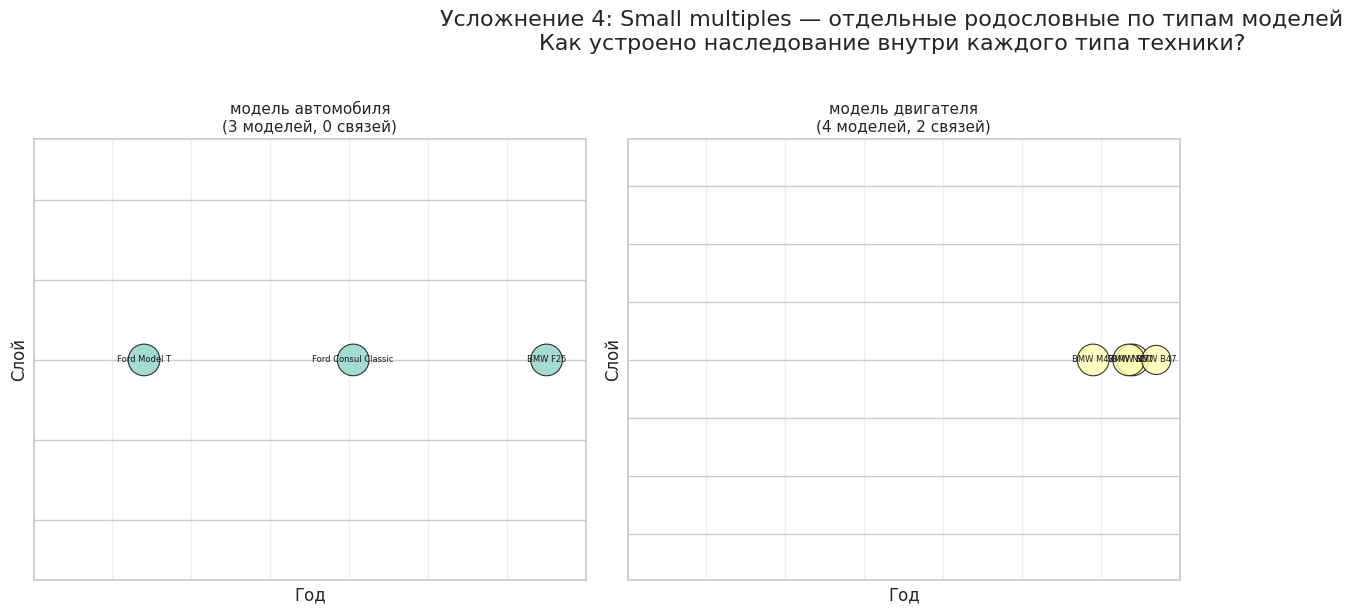


📌 СРАВНЕНИЕ ПЛОТНОСТИ ГРАФОВ ПО ТИПАМ:
   • модель двигателя: плотность 0.1667 (4 узлов, 2 рёбер)
   • модель автомобиля: плотность 0.0000 (3 узлов, 0 рёбер)

📌 ИССЛЕДОВАТЕЛЬСКИЙ ВОПРОС:
   Одинаково ли разворачиваются lineage-структуры у разных типов?
   → Наиболее связанный тип: модель двигателя (плотность 0.1667)
   → Наименее связанный тип: модель автомобиля (плотность 0.0000)


In [11]:
# ============================================================
# ЯЧЕЙКА 10. Усложнение 4: Small multiples — отдельные графы по типам
# ============================================================
# Преподаватель: «Если один общий граф перегружен, можно сделать несколько
# маленьких временных родословных: по одному графу на тип»
# Вопрос: одинаково ли разворачиваются lineage-структуры у разных типов техники?

import networkx as nx
import matplotlib.pyplot as plt

# --- 1. Определяем топ-типы для small multiples ---
type_counts = df_lineage_time["type_for_viz"].value_counts()
top_types = type_counts.head(6).index.tolist()
print(f"📊 Топ-6 типов для small multiples: {top_types}")
print(f"   Остальные типы объединяем в 'Other'")

# --- 2. Создаём графы для каждого типа ---
graphs_by_type = {}
stats_by_type = {}

for t in top_types:
    # Отбираем модели этого типа
    models_of_type = df_lineage_time[df_lineage_time["type_for_viz"] == t]["model_name"].tolist()

    # Строим подграф из отфильтрованного графа
    if len(models_of_type) > 1:
        # Берём исходный граф и фильтруем по узлам этого типа
        G_type = G_filtered.subgraph([n for n in G_filtered.nodes() if n in models_of_type]).copy()
        if G_type.number_of_nodes() > 0:
            graphs_by_type[t] = G_type
            stats_by_type[t] = {
                "nodes": G_type.number_of_nodes(),
                "edges": G_type.number_of_edges(),
                "density": nx.density(G_type) if G_type.number_of_nodes() > 0 else 0
            }

print(f"\n🔗 Построено {len(graphs_by_type)} графов по типам")

# --- 3. Small multiples визуализация ---
n_types = len(graphs_by_type)
n_cols = 3
n_rows = (n_types + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

for idx, (t, G_t) in enumerate(graphs_by_type.items()):
    ax = axes[idx]

    # Позиционирование внутри этого графа
    pos_t = {}
    for node in G_t.nodes():
        year = G_t.nodes[node].get("year")
        if pd.notna(year):
            same_year_nodes = [n for n in G_t.nodes() if G_t.nodes[n].get("year") == year]
            y_idx = same_year_nodes.index(node) if node in same_year_nodes else 0
            pos_t[node] = (year, -y_idx * 1.5)
        else:
            pos_t[node] = (1900, -len(pos_t) % 10)

    # Цвета: единый цвет для всех узлов этого типа
    node_colors_t = [plt.cm.Set3(idx % 12)] * len(G_t.nodes())
    node_sizes_t = [300 + 200 * np.log1p(G_t.nodes[n].get("degree", 1)) for n in G_t.nodes()]

    nx.draw_networkx_nodes(G_t, pos_t, node_color=node_colors_t, node_size=node_sizes_t,
                           alpha=0.8, edgecolors="black", linewidths=0.8, ax=ax)
    nx.draw_networkx_edges(G_t, pos_t, edge_color="gray", alpha=0.5,
                           arrows=True, arrowsize=8, arrowstyle="->", width=0.8, ax=ax)
    nx.draw_networkx_labels(G_t, pos_t, font_size=6, font_family="sans-serif", ax=ax)

    ax.set_title(f"{t}\n({stats_by_type[t]['nodes']} моделей, {stats_by_type[t]['edges']} связей)", fontsize=11)
    ax.set_xlabel("Год")
    ax.set_ylabel("Слой")
    ax.grid(True, axis="x", alpha=0.3)
    ax.set_xlim(1880, 2020)

# Скрываем лишние оси
for idx in range(len(graphs_by_type), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Усложнение 4: Small multiples — отдельные родословные по типам моделей\nКак устроено наследование внутри каждого типа техники?",
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("enhancement_4_small_multiples_by_type.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📌 СРАВНЕНИЕ ПЛОТНОСТИ ГРАФОВ ПО ТИПАМ:")
for t, stats in sorted(stats_by_type.items(), key=lambda x: x[1]["density"], reverse=True):
    print(f"   • {t}: плотность {stats['density']:.4f} ({stats['nodes']} узлов, {stats['edges']} рёбер)")

print("\n📌 ИССЛЕДОВАТЕЛЬСКИЙ ВОПРОС:")
print("   Одинаково ли разворачиваются lineage-структуры у разных типов?")
highest_density = max(stats_by_type.items(), key=lambda x: x[1]["density"])
lowest_density = min(stats_by_type.items(), key=lambda x: x[1]["density"])
print(f"   → Наиболее связанный тип: {highest_density[0]} (плотность {highest_density[1]['density']:.4f})")
print(f"   → Наименее связанный тип: {lowest_density[0]} (плотность {lowest_density[1]['density']:.4f})")

🔍 Найдено 9 аномалий:
   • Ford Model T: смена типа: unknown → модель автомобиля
   • Ford Model A: смена типа: модель автомобиля → unknown
   • Ford Consul Classic: смена типа: unknown → модель автомобиля
   • Ford Corsair: смена типа: модель автомобиля → unknown
   • BMW G01: смена типа: модель автомобиля → unknown
   • BMW M47: смена типа: unknown → модель двигателя
   • BMW N57: смена типа: unknown → модель двигателя
   • BMW F25: смена типа: unknown → модель автомобиля
   • BMW B57: смена типа: модель двигателя → unknown


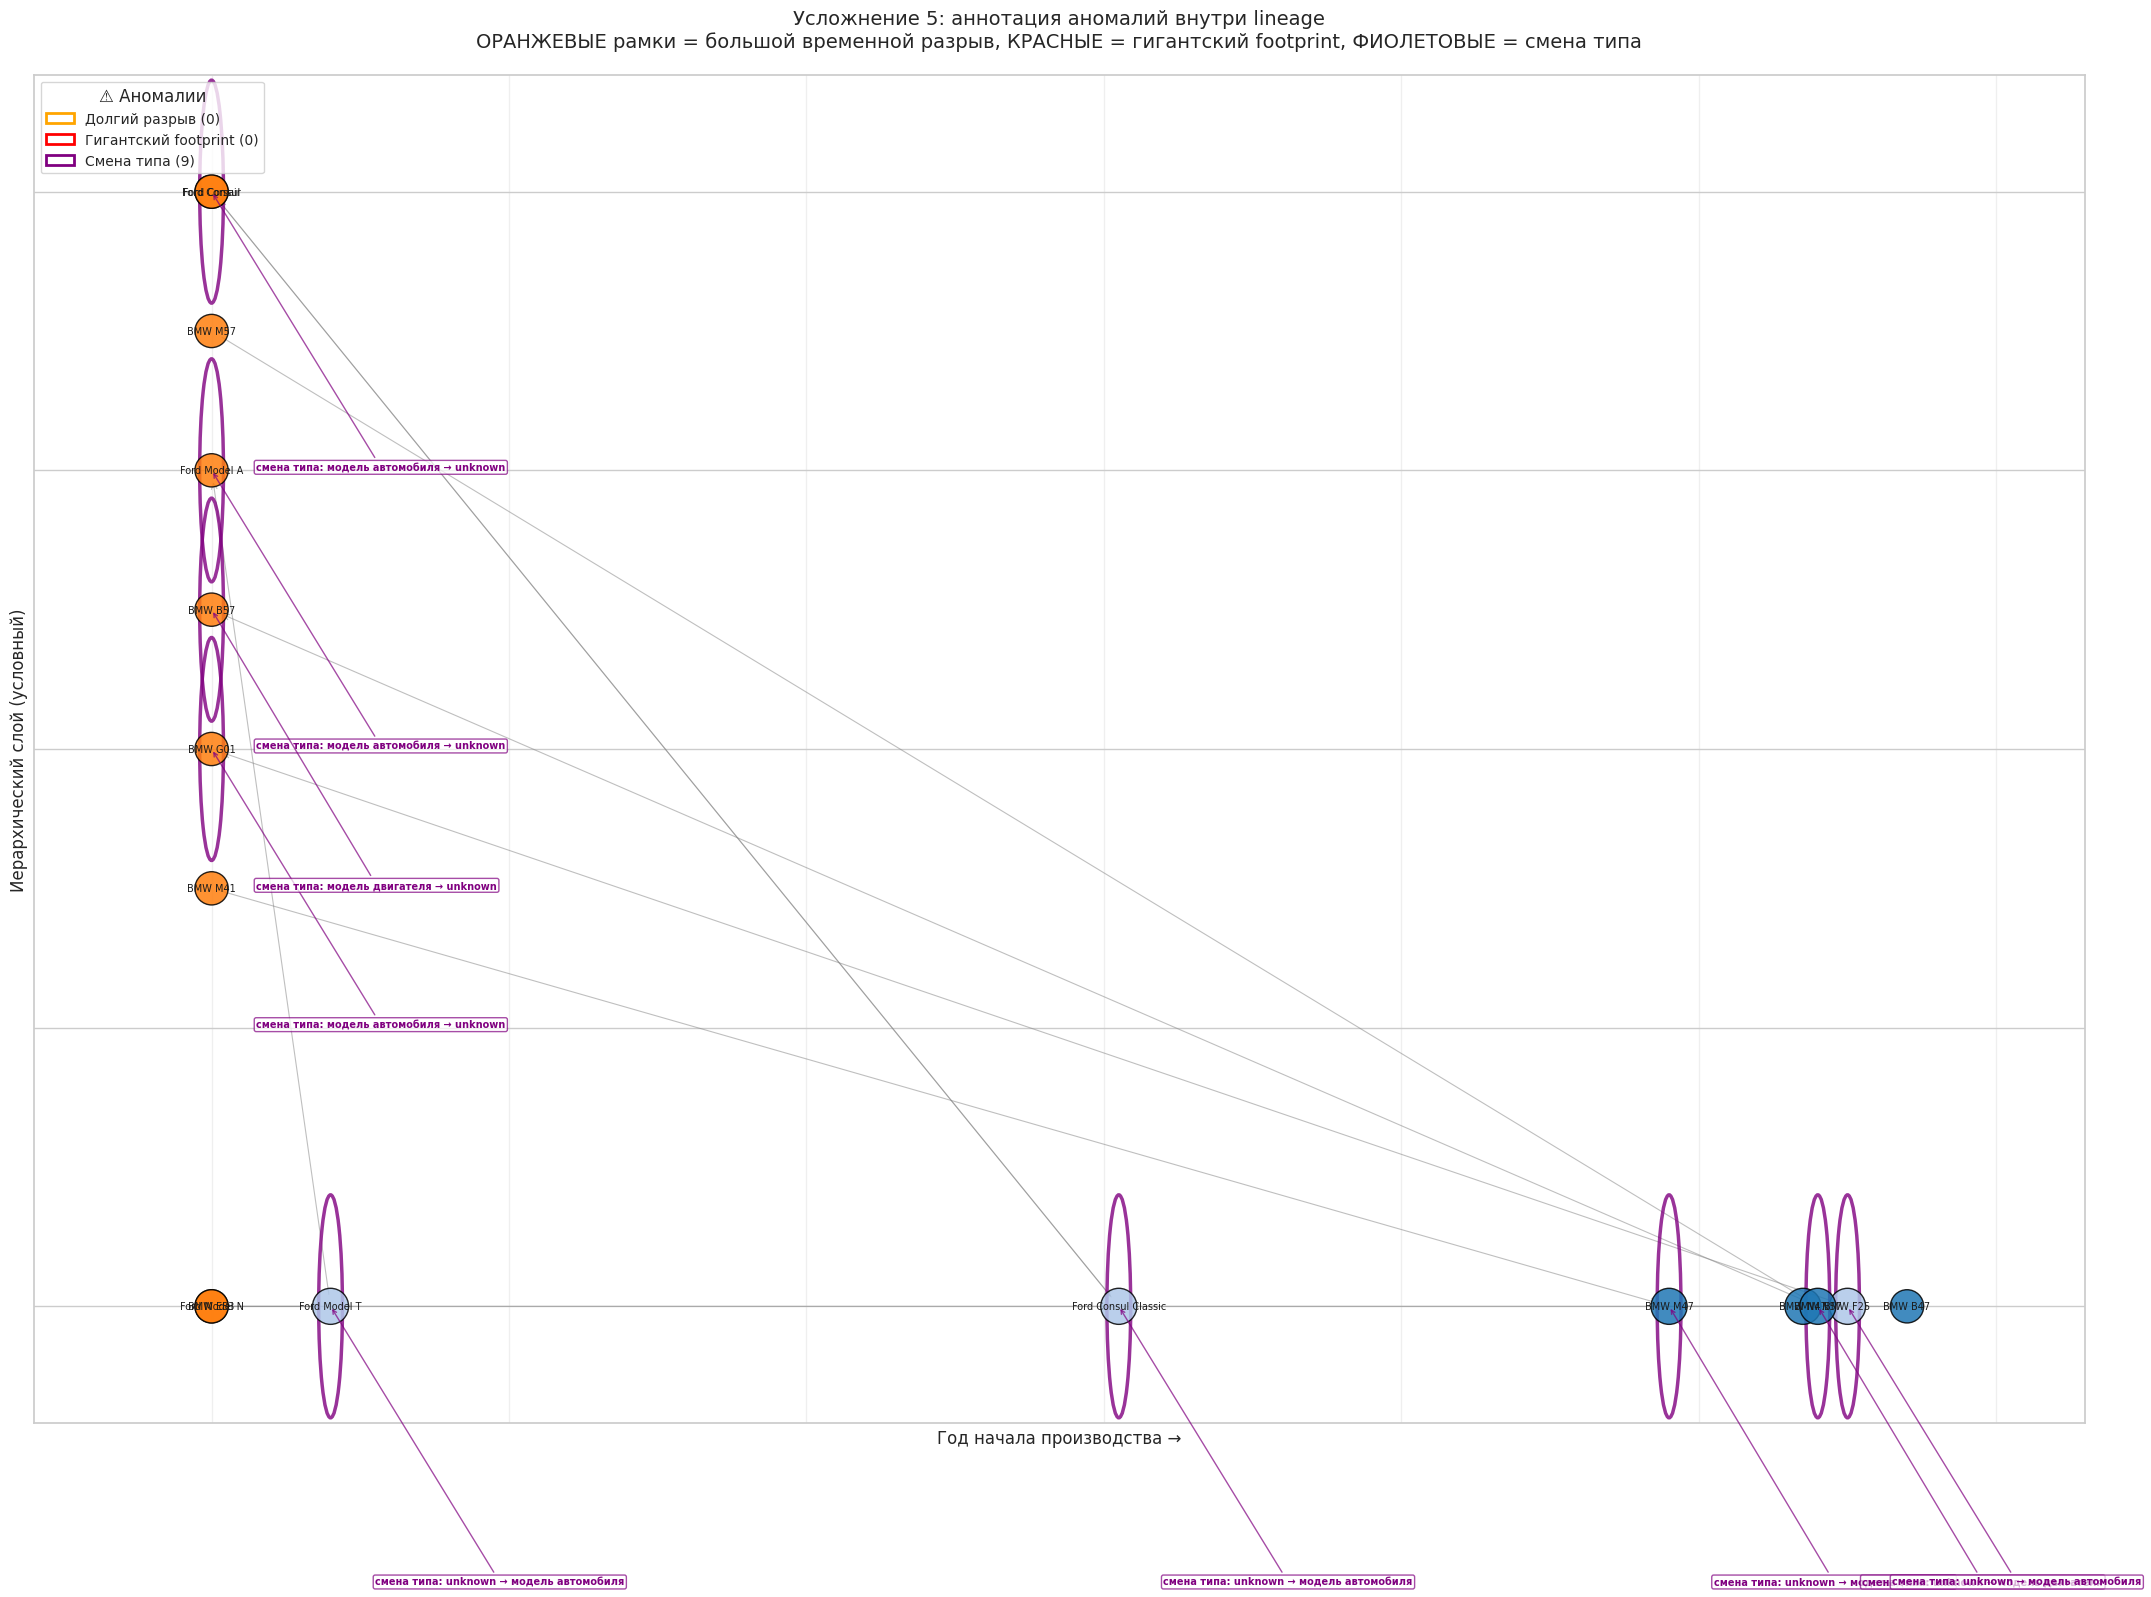


📌 СЮЖЕТНЫЕ ПОВОРОТЫ (аномалии в родословной):
   ⚠️ Долгие разрывы — модели, появившиеся спустя десятилетия после предшественника
   ⚠️ Гигантский footprint — модели, резко отличающиеся по габаритам от контекста
   ⚠️ Смена типа — ветви, где наследование перешло в другой класс техники


In [12]:
# ============================================================
# ЯЧЕЙКА 11. Усложнение 5: аннотация аномалий внутри lineage
# ============================================================
# Преподаватель: «Граф становится не просто картой, а картой с сюжетными поворотами.
# Выброс надо либо подписывать, либо отдельно обсуждать, а не молча терять»

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, FancyBboxPatch
import matplotlib.patches as mpatches

# --- 1. Берём отфильтрованный граф ---
G_anom = G_filtered.copy()

# --- 2. Ищем аномалии разных типов ---
anomalies = []

# Аномалия 1: необычно большой временной разрыв между поколениями
for u, v in G_anom.edges():
    year_u = G_anom.nodes[u].get("year")
    year_v = G_anom.nodes[v].get("year")
    if pd.notna(year_u) and pd.notna(year_v):
        gap = year_v - year_u
        if gap > 30:  # разрыв более 30 лет
            anomalies.append({
                "type": "long_gap",
                "node": v,
                "description": f"разрыв {int(gap)} лет после {u}",
                "color": "orange",
                "year": year_v
            })

# Аномалия 2: необычно большой footprint
footprints = {node: G_anom.nodes[node].get("footprint", np.nan) for node in G_anom.nodes()}
valid_fp = {k: v for k, v in footprints.items() if pd.notna(v)}
if valid_fp:
    fp_mean = np.mean(list(valid_fp.values()))
    fp_std = np.std(list(valid_fp.values()))
    for node, fp in valid_fp.items():
        if fp > fp_mean + 2 * fp_std:  # выброс по footprint
            anomalies.append({
                "type": "large_footprint",
                "node": node,
                "description": f"гигант: footprint={fp:.0f}",
                "color": "red",
                "year": G_anom.nodes[node].get("year", 0)
            })

# Аномалия 3: смена типа внутри одной ветви (если есть данные)
type_map = {node: G_anom.nodes[node].get("type", "") for node in G_anom.nodes()}
for u, v in G_anom.edges():
    if type_map.get(u) and type_map.get(v) and type_map[u] != type_map[v]:
        anomalies.append({
            "type": "type_switch",
            "node": v,
            "description": f"смена типа: {type_map[u]} → {type_map[v]}",
            "color": "purple",
            "year": G_anom.nodes[v].get("year", 0)
        })

# Убираем дубликаты по узлам
seen_nodes = set()
unique_anomalies = []
for a in sorted(anomalies, key=lambda x: x.get("year", 0)):
    if a["node"] not in seen_nodes:
        seen_nodes.add(a["node"])
        unique_anomalies.append(a)

print(f"🔍 Найдено {len(unique_anomalies)} аномалий:")
for a in unique_anomalies[:10]:
    print(f"   • {a['node']}: {a['description']}")

# --- 3. Позиционирование ---
pos_anom = {}
for node in G_anom.nodes():
    year = G_anom.nodes[node].get("year")
    if pd.notna(year):
        same_year_nodes = [n for n in G_anom.nodes() if G_anom.nodes[n].get("year") == year]
        y_idx = same_year_nodes.index(node) if node in same_year_nodes else 0
        pos_anom[node] = (year, -y_idx * 2)
    else:
        pos_anom[node] = (1900, -len(pos_anom) % 10)

# --- 4. Визуализация с аннотациями ---
plt.figure(figsize=(22, 16))

# Цвета узлов по типу
types_anom = list(set(nx.get_node_attributes(G_anom, "type").values()))
type_colors_anom = plt.cm.tab20.colors[:len(types_anom)]
color_map_anom = {t: type_colors_anom[i] for i, t in enumerate(types_anom)}
node_colors_anom = [color_map_anom.get(G_anom.nodes[n]["type"], "#cccccc") for n in G_anom.nodes()]
node_sizes_anom = [400 + 250 * np.log1p(G_anom.nodes[n].get("degree", 1)) for n in G_anom.nodes()]

# Рисуем граф
nx.draw_networkx_nodes(G_anom, pos_anom, node_color=node_colors_anom, node_size=node_sizes_anom,
                       alpha=0.85, edgecolors="black", linewidths=1)
nx.draw_networkx_edges(G_anom, pos_anom, edge_color="gray", alpha=0.5,
                       arrows=True, arrowsize=10, arrowstyle="->", width=0.8)
nx.draw_networkx_labels(G_anom, pos_anom, font_size=7, font_family="sans-serif")

# Рисуем аннотации для аномалий
for anomaly in unique_anomalies:
    node = anomaly["node"]
    if node in pos_anom:
        x, y = pos_anom[node]
        color = anomaly["color"]

        # Рисуем рамку вокруг аномального узла
        circle = plt.Circle((x, y), radius=0.8, color=color, fill=False, linewidth=2.5, alpha=0.8)
        plt.gca().add_patch(circle)

        # Добавляем текст-аннотацию
        plt.annotate(anomaly["description"],
                    xy=(x, y), xytext=(x + 3, y - 2),
                    fontsize=7, color=color, weight="bold",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor=color),
                    arrowprops=dict(arrowstyle="->", color=color, lw=1, alpha=0.7))

plt.title("Усложнение 5: аннотация аномалий внутри lineage\nОРАНЖЕВЫЕ рамки = большой временной разрыв, КРАСНЫЕ = гигантский footprint, ФИОЛЕТОВЫЕ = смена типа",
          fontsize=14, pad=20)
plt.xlabel("Год начала производства →", fontsize=12)
plt.ylabel("Иерархический слой (условный)", fontsize=12)
plt.grid(True, axis="x", alpha=0.3)

# Легенда аномалий
anomaly_legend = [
    mpatches.Patch(facecolor="none", edgecolor="orange", linewidth=2, label=f"Долгий разрыв ({sum(1 for a in unique_anomalies if a['type']=='long_gap')})"),
    mpatches.Patch(facecolor="none", edgecolor="red", linewidth=2, label=f"Гигантский footprint ({sum(1 for a in unique_anomalies if a['type']=='large_footprint')})"),
    mpatches.Patch(facecolor="none", edgecolor="purple", linewidth=2, label=f"Смена типа ({sum(1 for a in unique_anomalies if a['type']=='type_switch')})")
]

plt.legend(handles=anomaly_legend, loc="upper left", fontsize=10, title="⚠️ Аномалии")

plt.tight_layout()
plt.savefig("enhancement_5_anomalies_annotation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📌 СЮЖЕТНЫЕ ПОВОРОТЫ (аномалии в родословной):")
print("   ⚠️ Долгие разрывы — модели, появившиеся спустя десятилетия после предшественника")
print("   ⚠️ Гигантский footprint — модели, резко отличающиеся по габаритам от контекста")
print("   ⚠️ Смена типа — ветви, где наследование перешло в другой класс техники")

## 🏆 Финальное сравнение всех вариантов визуализации

### Базовые черновики (по методичке)

| Черновик | Сильные стороны | Слабые стороны | Вердикт |
|----------|----------------|----------------|---------|
| **A: Полный граф** | Показывает всё | Лапша при >50 узлах | ❌ Бракуем |
| **B: По десятилетиям** | Снижает шум | Теряет точные даты | ✅ Для отчёта |
| **C: Топ-компоненты** | Виден скелет эволюции | Потеряны мелкие ветви | ✅ Для отчёта |

### Усложнения (премиум-варианты)

| Усложнение | Что добавляет | Когда использовать |
|------------|---------------|-------------------|
| **1: Цвет ребра** | Внутри/между производителями | Для вопроса о брендовом наследовании |
| **2: Размер = footprint** | Эволюция телесности | Если важны габариты моделей |
| **3: Прозрачность** | Полнота знаний в Wikidata | Чтобы не доверять слепо пробелам |
| **4: Small multiples** | Сравнение типов | При сильной перегруженности |
| **5: Аннотации** | Сюжетные повороты | Для сторителлинга |

### 🥇 Лучший вариант для финального отчёта

**Рекомендую комбинацию:**
- **База:** Черновик C (только крупнейшие компоненты)
- **Усложнение 1** (цвет ребра = производитель) — добавляет глубину
- **Усложнение 5** (аннотации аномалий) — добавляет нарратив

**Итоговый исследовательский вопрос:**
> *Как разворачиваются во времени семейства моделей, какие узлы становятся опорными предками, и сохраняется ли производитель и тип модели вдоль родословной?*

### 📊 Что мы открыли с помощью этих визуализаций:

1. **Несколько больших семейств** вместо единого дерева
2. **Модели-«патриархи»** с высокой степенью влияния3. **Длинные цепочки** наследования через десятилетия
4. **Переходы между производителями** (красные рёбра)
5. **Аномалии** — разрывы, гиганты, смены типа